GROUP 1: FOUNDATION - DESCRIPTIVE STATISTICS

1. SAMPLE OVERVIEW

Total Responses: 96

Consent:
  Consented: 91 (94.8%)
  Did not consent: 5 (5.2%)

Encounter Prevalence:
  Had encounter: 32 (35.2% of consenters)
  No encounter: 54 (59.3% of consenters)

Engagement (among those with encounters, n=37):
  No engagement: 21 (56.8%)
  Brief engagement: 13 (35.1%)
  Paid: 3 (8.1%)

Survey Timeline:
  Collection period: 2025-10-07 to 2025-11-01
  Duration: 25 days

2. DEMOGRAPHICS

Community Relation (n=84):
  Current student: 71 (84.5%)
  Staff member: 7 (8.3%)
  Alumni: 3 (3.6%)
  Family member of student/faculty/staff: 3 (3.6%)

Age Distribution (n=91):
  18–20: 58 (63.7%)
  21–24: 21 (23.1%)
  25–29: 5 (5.5%)
  30–39: 2 (2.2%)
  40-49: 1 (1.1%)
  40–49: 1 (1.1%)
  50+: 2 (2.2%)
  Below 18: 1 (1.1%)

Current Status (n=91):
  Student, Preparing for jobs/internships: 38 (41.8%)
  Student: 37 (40.7%)
  Employed (full/part-time): 9 (9.9%)
  Prefer not to say: 3 (3.3%)
  Employed (full/part-ti

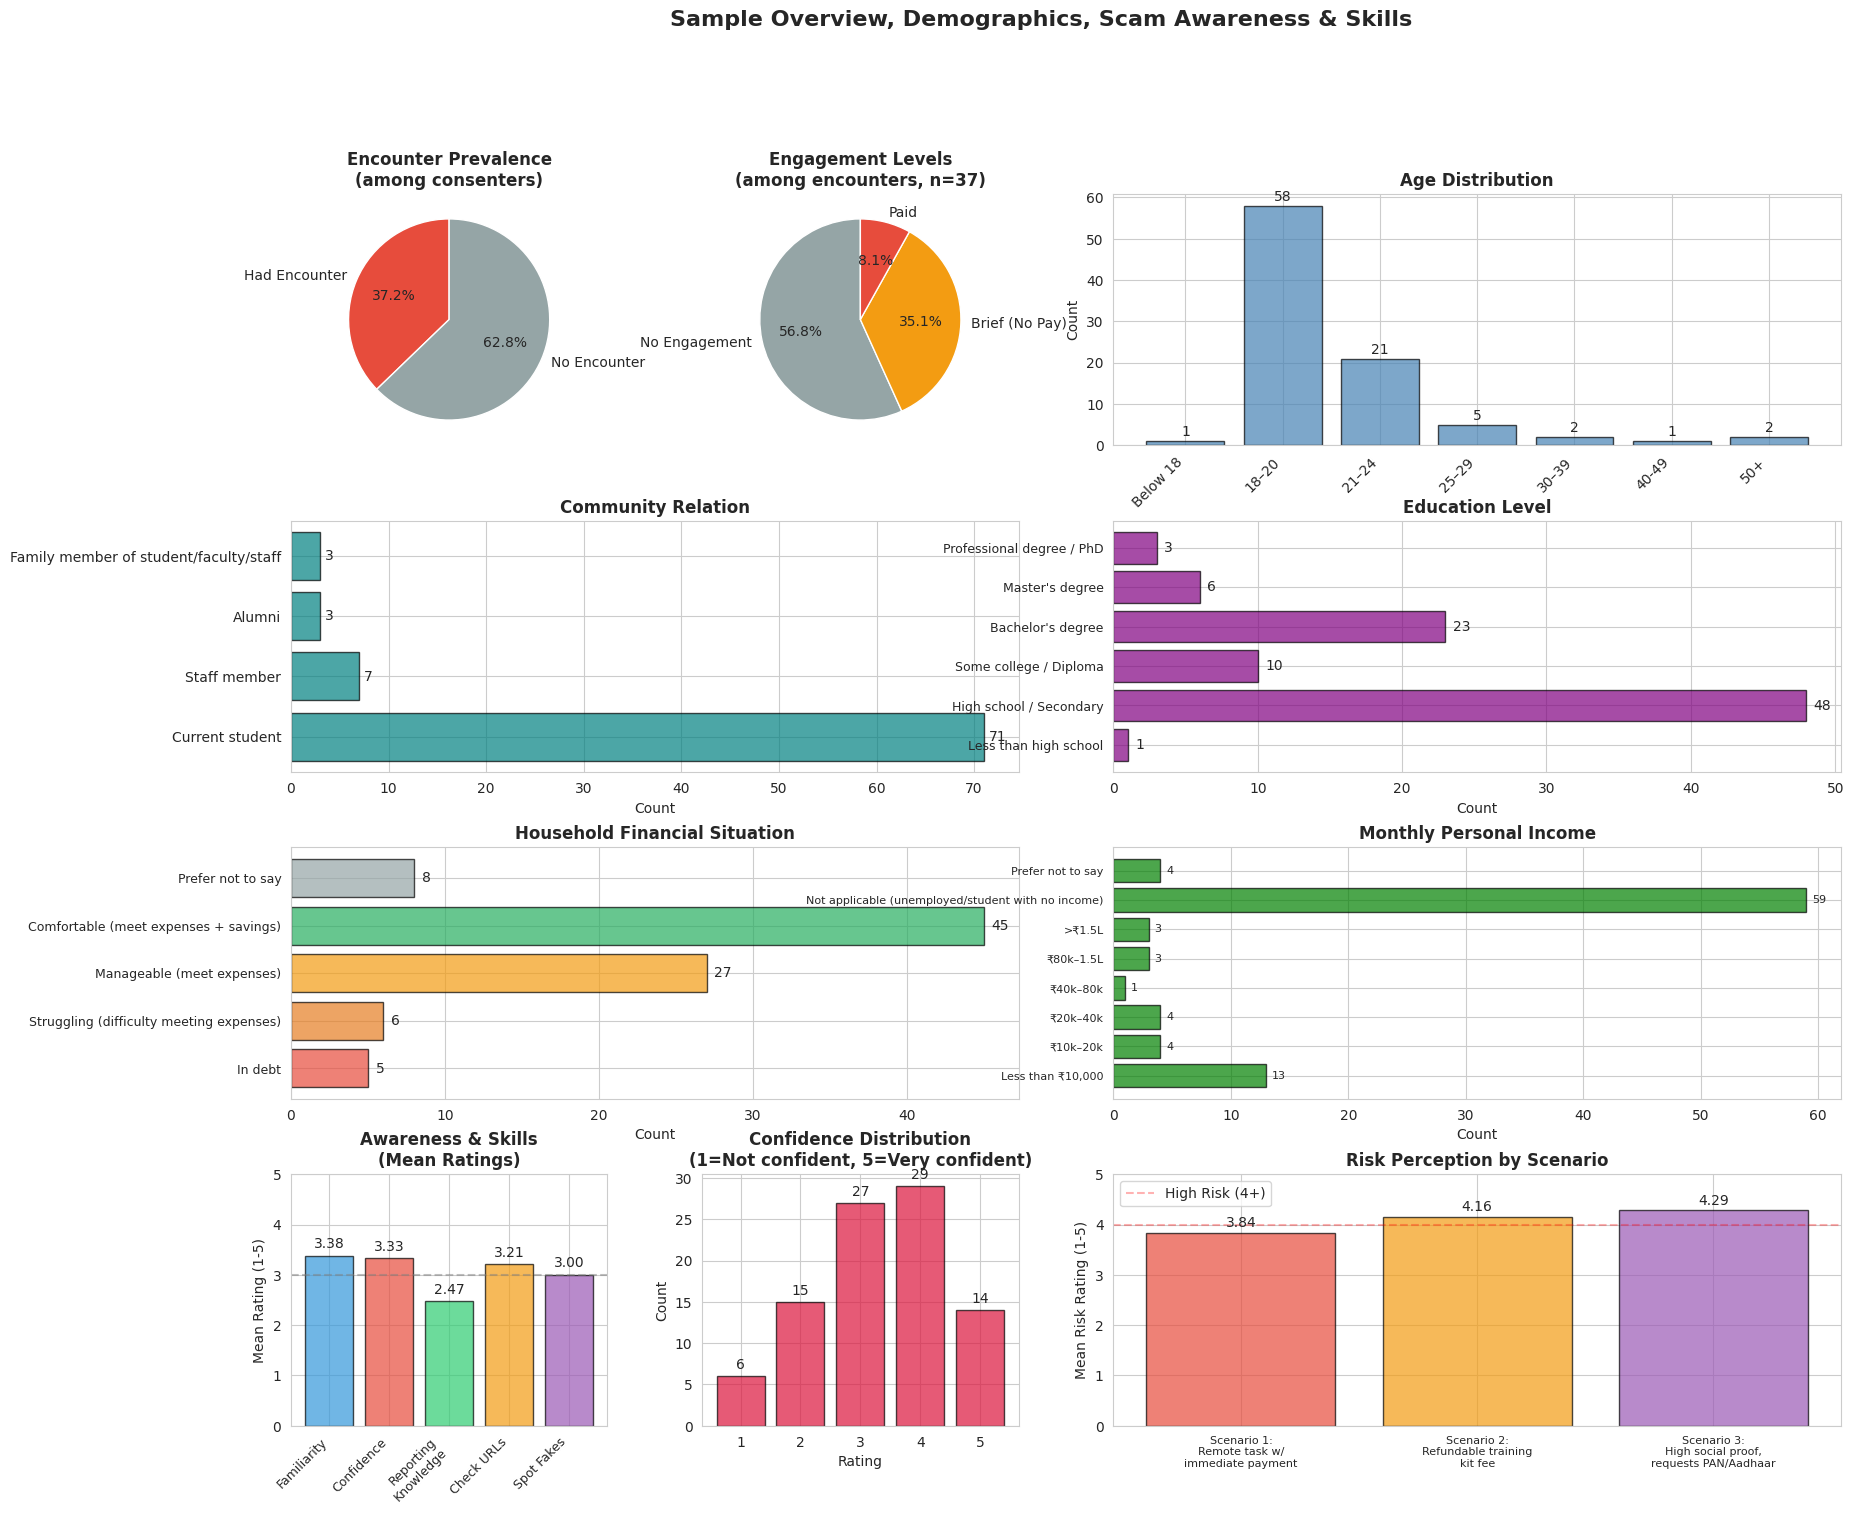

In [1]:
"""
GROUP 1: FOUNDATION - DESCRIPTIVE STATISTICS
Sample Overview, Demographics, Scam Awareness & Skills

Pure descriptive - frequencies, percentages, distributions
NO hypothesis testing, NO p-values
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_excel('responses.xlsx')

print("="*80)
print("GROUP 1: FOUNDATION - DESCRIPTIVE STATISTICS")
print("="*80)

# ============================================================================
# 1. SAMPLE OVERVIEW
# ============================================================================

print("\n" + "="*80)
print("1. SAMPLE OVERVIEW")
print("="*80)

# Basic counts
total_responses = len(df)
consent_col = 'Do you consent to participate in this research?'
consented = (df[consent_col] == 'I consent').sum()

# Encounter status
encounter_col = 'In the past 12 months, have you personally encountered any suspicious job/internship offers or tasks?'
had_encounter = (df[encounter_col] == 'Yes').sum()
no_encounter = (df[encounter_col] == 'No').sum()

# Engagement
engage_col = 'Did you engage with it at all?'
engaged = df[engage_col].notna().sum()

# Payment
paid_engage = (df[engage_col] == 'Yes, including payment').sum()
paid_brief = (df[engage_col] == 'Yes, briefly (no payment)').sum()
no_engage = (df[engage_col] == 'No').sum()

print(f"\nTotal Responses: {total_responses}")
print(f"\nConsent:")
print(f"  Consented: {consented} ({consented/total_responses*100:.1f}%)")
print(f"  Did not consent: {total_responses - consented} ({(total_responses-consented)/total_responses*100:.1f}%)")

print(f"\nEncounter Prevalence:")
print(f"  Had encounter: {had_encounter} ({had_encounter/consented*100:.1f}% of consenters)")
print(f"  No encounter: {no_encounter} ({no_encounter/consented*100:.1f}% of consenters)")

print(f"\nEngagement (among those with encounters, n={engaged}):")
print(f"  No engagement: {no_engage} ({no_engage/engaged*100:.1f}%)")
print(f"  Brief engagement: {paid_brief} ({paid_brief/engaged*100:.1f}%)")
print(f"  Paid: {paid_engage} ({paid_engage/engaged*100:.1f}%)")

# Timeline
print(f"\nSurvey Timeline:")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
start_date = df['Timestamp'].min()
end_date = df['Timestamp'].max()
duration = (end_date - start_date).days
print(f"  Collection period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"  Duration: {duration} days")

# ============================================================================
# 2. DEMOGRAPHICS
# ============================================================================

print("\n" + "="*80)
print("2. DEMOGRAPHICS")
print("="*80)

# Community relation
community_col = 'Community relation (select one)'
print(f"\nCommunity Relation (n={df[community_col].notna().sum()}):")
community_dist = df[community_col].value_counts()
for relation, count in community_dist.items():
    pct = count / df[community_col].notna().sum() * 100
    print(f"  {relation}: {count} ({pct:.1f}%)")

# Age
age_col = 'Age band'
print(f"\nAge Distribution (n={df[age_col].notna().sum()}):")
age_dist = df[age_col].value_counts().sort_index()
for age, count in age_dist.items():
    pct = count / df[age_col].notna().sum() * 100
    print(f"  {age}: {count} ({pct:.1f}%)")

# Current status
status_col = 'Current status (select all that apply)'
print(f"\nCurrent Status (n={df[status_col].notna().sum()}):")
status_dist = df[status_col].value_counts()
for status, count in status_dist.head(10).items():
    pct = count / df[status_col].notna().sum() * 100
    print(f"  {status}: {count} ({pct:.1f}%)")

# Education
edu_col = 'Highest education level completed'
print(f"\nEducation Level (n={df[edu_col].notna().sum()}):")
edu_dist = df[edu_col].value_counts()
for edu, count in edu_dist.items():
    pct = count / df[edu_col].notna().sum() * 100
    print(f"  {edu}: {count} ({pct:.1f}%)")

# Country
country_col = 'Country/region of usual residence'
print(f"\nCountry/Region (n={df[country_col].notna().sum()}):")
country_dist = df[country_col].value_counts()
for country, count in country_dist.items():
    pct = count / df[country_col].notna().sum() * 100
    print(f"  {country}: {count} ({pct:.1f}%)")

# State (India only)
state_col = 'State(if India)'
india_states = df[df[country_col] == 'India'][state_col].value_counts()
if len(india_states) > 0:
    print(f"\nState Distribution (India only, n={india_states.sum()}):")
    for state, count in india_states.head(10).items():
        pct = count / india_states.sum() * 100
        print(f"  {state}: {count} ({pct:.1f}%)")

# Income
income_col = 'Current monthly personal income (approx.)'
print(f"\nMonthly Income (n={df[income_col].notna().sum()}):")
income_dist = df[income_col].value_counts()
for income, count in income_dist.items():
    pct = count / df[income_col].notna().sum() * 100
    print(f"  {income}: {count} ({pct:.1f}%)")

# Financial situation
financial_col = 'Household financial situation'
print(f"\nHousehold Financial Situation (n={df[financial_col].notna().sum()}):")
financial_dist = df[financial_col].value_counts()
for situation, count in financial_dist.items():
    pct = count / df[financial_col].notna().sum() * 100
    print(f"  {situation}: {count} ({pct:.1f}%)")

# ============================================================================
# 3. SCAM AWARENESS & SKILLS
# ============================================================================

print("\n" + "="*80)
print("3. SCAM AWARENESS & SKILLS")
print("="*80)

# Familiarity
familiarity_col = 'Before today, how familiar were you with the idea of job scams?'
print(f"\nFamiliarity with Job Scams (n={df[familiarity_col].notna().sum()}):")
familiarity_dist = df[familiarity_col].value_counts().sort_index()
for rating, count in familiarity_dist.items():
    pct = count / df[familiarity_col].notna().sum() * 100
    print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
mean_fam = df[familiarity_col].mean()
median_fam = df[familiarity_col].median()
print(f"  Mean: {mean_fam:.2f}, Median: {median_fam:.1f}")

# Confidence
confidence_col = 'How confident are you that you can recognize a job scam when you see one?'
print(f"\nConfidence in Recognizing Scams (n={df[confidence_col].notna().sum()}):")
confidence_dist = df[confidence_col].value_counts().sort_index()
for rating, count in confidence_dist.items():
    pct = count / df[confidence_col].notna().sum() * 100
    print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
mean_conf = df[confidence_col].mean()
median_conf = df[confidence_col].median()
print(f"  Mean: {mean_conf:.2f}, Median: {median_conf:.1f}")

# Knowledge of reporting
reporting_col = 'I know where and how to report suspicious offers.'
print(f"\nKnowledge of Reporting Channels (n={df[reporting_col].notna().sum()}):")
reporting_dist = df[reporting_col].value_counts().sort_index()
for rating, count in reporting_dist.items():
    pct = count / df[reporting_col].notna().sum() * 100
    print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
mean_rep = df[reporting_col].mean()
median_rep = df[reporting_col].median()
print(f"  Mean: {mean_rep:.2f}, Median: {median_rep:.1f}")

# Verification checks
checks_col = 'Which checks do you usually perform before applying? (select all that apply)'
print(f"\nVerification Checks Performed (n={df[checks_col].notna().sum()}):")
# Parse multi-select
all_checks = []
for checks in df[checks_col].dropna():
    if isinstance(checks, str):
        all_checks.extend([c.strip() for c in checks.split(',')])
from collections import Counter
checks_counter = Counter(all_checks)
total_responses_checks = df[checks_col].notna().sum()
for check, count in checks_counter.most_common():
    pct = count / total_responses_checks * 100
    print(f"  {check}: {count} ({pct:.1f}%)")

# Technical comfort - URLs
url_col = 'How comfortable are you with: Checking URLs/domains'
print(f"\nComfort with Checking URLs/Domains (n={df[url_col].notna().sum()}):")
url_dist = df[url_col].value_counts().sort_index()
for rating, count in url_dist.items():
    pct = count / df[url_col].notna().sum() * 100
    print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
mean_url = df[url_col].mean()
median_url = df[url_col].median()
print(f"  Mean: {mean_url:.2f}, Median: {median_url:.1f}")

# Technical comfort - Spotting fakes
fake_col = 'How comfortable are you with: Spotting impersonation/lookalike pages'
print(f"\nComfort with Spotting Fakes (n={df[fake_col].notna().sum()}):")
fake_dist = df[fake_col].value_counts().sort_index()
for rating, count in fake_dist.items():
    pct = count / df[fake_col].notna().sum() * 100
    print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
mean_fake = df[fake_col].mean()
median_fake = df[fake_col].median()
print(f"  Mean: {mean_fake:.2f}, Median: {median_fake:.1f}")

# Risk perception scenarios
risk_cols = [col for col in df.columns if 'How risky do you perceive this scenario to be?' in col]
for i, risk_col in enumerate(risk_cols, 1):
    print(f"\nRisk Perception - Scenario {i} (n={df[risk_col].notna().sum()}):")
    risk_dist = df[risk_col].value_counts().sort_index()
    for rating, count in risk_dist.items():
        pct = count / df[risk_col].notna().sum() * 100
        print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
    mean_risk = df[risk_col].mean()
    median_risk = df[risk_col].median()
    print(f"  Mean: {mean_risk:.2f}, Median: {median_risk:.1f}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# Row 1: Sample Overview
ax1 = fig.add_subplot(gs[0, 0])
encounter_data = pd.Series({
    'Had Encounter': had_encounter,
    'No Encounter': no_encounter
})
colors_encounter = ['#e74c3c', '#95a5a6']
ax1.pie(encounter_data, labels=encounter_data.index, autopct='%1.1f%%', 
        startangle=90, colors=colors_encounter)
ax1.set_title('Encounter Prevalence\n(among consenters)', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
engagement_data = pd.Series({
    'No Engagement': no_engage,
    'Brief (No Pay)': paid_brief,
    'Paid': paid_engage
})
colors_engage = ['#95a5a6', '#f39c12', '#e74c3c']
ax2.pie(engagement_data, labels=engagement_data.index, autopct='%1.1f%%',
        startangle=90, colors=colors_engage)
ax2.set_title('Engagement Levels\n(among encounters, n=37)', fontweight='bold')

# Age distribution
ax3 = fig.add_subplot(gs[0, 2:])
age_order = ['Below 18', '18–20', '21–24', '25–29', '30–39', '40-49', '50+']
age_counts = [age_dist.get(age, 0) for age in age_order]
ax3.bar(range(len(age_order)), age_counts, color='steelblue', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(age_order)))
ax3.set_xticklabels(age_order, rotation=45, ha='right')
ax3.set_ylabel('Count')
ax3.set_title('Age Distribution', fontweight='bold')
for i, count in enumerate(age_counts):
    if count > 0:
        ax3.text(i, count + 0.5, str(count), ha='center', va='bottom')

# Row 2: Demographics
ax4 = fig.add_subplot(gs[1, 0:2])
community_top = community_dist.head(5)
ax4.barh(range(len(community_top)), community_top.values, color='teal', alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(community_top)))
ax4.set_yticklabels(community_top.index)
ax4.set_xlabel('Count')
ax4.set_title('Community Relation', fontweight='bold')
for i, count in enumerate(community_top.values):
    ax4.text(count + 0.5, i, str(count), va='center')

ax5 = fig.add_subplot(gs[1, 2:])
edu_order = [
    'Less than high school',
    'High school / Secondary',
    'Some college / Diploma',
    "Bachelor's degree",
    "Master's degree",
    'Professional degree / PhD'
]
edu_counts = [edu_dist.get(edu, 0) for edu in edu_order]
ax5.barh(range(len(edu_order)), edu_counts, color='purple', alpha=0.7, edgecolor='black')
ax5.set_yticks(range(len(edu_order)))
ax5.set_yticklabels(edu_order, fontsize=9)
ax5.set_xlabel('Count')
ax5.set_title('Education Level', fontweight='bold')
for i, count in enumerate(edu_counts):
    if count > 0:
        ax5.text(count + 0.5, i, str(count), va='center')

# Row 3: Financial
ax6 = fig.add_subplot(gs[2, 0:2])
financial_order = [
    'In debt',
    'Struggling (difficulty meeting expenses)',
    'Manageable (meet expenses)',
    'Comfortable (meet expenses + savings)',
    'Prefer not to say'
]
fin_counts = [financial_dist.get(f, 0) for f in financial_order]
colors_fin = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#95a5a6']
ax6.barh(range(len(financial_order)), fin_counts, color=colors_fin, alpha=0.7, edgecolor='black')
ax6.set_yticks(range(len(financial_order)))
ax6.set_yticklabels(financial_order, fontsize=9)
ax6.set_xlabel('Count')
ax6.set_title('Household Financial Situation', fontweight='bold')
for i, count in enumerate(fin_counts):
    if count > 0:
        ax6.text(count + 0.5, i, str(count), va='center')

# Income
ax7 = fig.add_subplot(gs[2, 2:])
income_order = [
    'Less than ₹10,000',
    '₹10k–20k',
    '₹20k–40k',
    '₹40k–80k',
    '₹80k–1.5L',
    '>₹1.5L',
    'Not applicable (unemployed/student with no income)',
    'Prefer not to say'
]
income_counts = [income_dist.get(inc, 0) for inc in income_order]
ax7.barh(range(len(income_order)), income_counts, color='green', alpha=0.7, edgecolor='black')
ax7.set_yticks(range(len(income_order)))
ax7.set_yticklabels(income_order, fontsize=8)
ax7.set_xlabel('Count')
ax7.set_title('Monthly Personal Income', fontweight='bold')
for i, count in enumerate(income_counts):
    if count > 0:
        ax7.text(count + 0.5, i, str(count), va='center', fontsize=8)

# Row 4: Awareness & Skills
ax8 = fig.add_subplot(gs[3, 0])
awareness_metrics = {
    'Familiarity': mean_fam,
    'Confidence': mean_conf,
    'Reporting\nKnowledge': mean_rep,
    'Check URLs': mean_url,
    'Spot Fakes': mean_fake
}
ax8.bar(range(len(awareness_metrics)), awareness_metrics.values(), 
        color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'],
        alpha=0.7, edgecolor='black')
ax8.set_xticks(range(len(awareness_metrics)))
ax8.set_xticklabels(awareness_metrics.keys(), rotation=45, ha='right', fontsize=9)
ax8.set_ylabel('Mean Rating (1-5)')
ax8.set_ylim([0, 5])
ax8.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax8.set_title('Awareness & Skills\n(Mean Ratings)', fontweight='bold')
for i, (label, value) in enumerate(awareness_metrics.items()):
    ax8.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

# Confidence distribution
ax9 = fig.add_subplot(gs[3, 1])
conf_counts = [confidence_dist.get(float(i), 0) for i in range(1, 6)]
ax9.bar(range(1, 6), conf_counts, color='crimson', alpha=0.7, edgecolor='black')
ax9.set_xlabel('Rating')
ax9.set_ylabel('Count')
ax9.set_title('Confidence Distribution\n(1=Not confident, 5=Very confident)', fontweight='bold')
ax9.set_xticks(range(1, 6))
for i, count in enumerate(conf_counts, 1):
    if count > 0:
        ax9.text(i, count + 0.5, str(count), ha='center', va='bottom')

# Risk perception
ax10 = fig.add_subplot(gs[3, 2:])
risk_means = [df[col].mean() for col in risk_cols]
risk_labels = [
    'Scenario 1:\nRemote task w/\nimmediate payment',
    'Scenario 2:\nRefundable training\nkit fee',
    'Scenario 3:\nHigh social proof,\nrequests PAN/Aadhaar'
]
ax10.bar(range(len(risk_means)), risk_means, 
        color=['#e74c3c', '#f39c12', '#9b59b6'],
        alpha=0.7, edgecolor='black')
ax10.set_xticks(range(len(risk_means)))
ax10.set_xticklabels(risk_labels, fontsize=8)
ax10.set_ylabel('Mean Risk Rating (1-5)')
ax10.set_ylim([0, 5])
ax10.axhline(y=4, color='red', linestyle='--', alpha=0.3, label='High Risk (4+)')
ax10.set_title('Risk Perception by Scenario', fontweight='bold')
for i, value in enumerate(risk_means):
    ax10.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')
ax10.legend()

plt.suptitle('Sample Overview, Demographics, Scam Awareness & Skills',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('group1_descriptive_stats.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: group1_descriptive_stats.png")

print("\n" + "="*80)
print("GROUP 1 ANALYSIS COMPLETE")
print("="*80)
print("\nKey Takeaways:")
print(f"  • {total_responses} total responses, {consented} consented ({consented/total_responses*100:.1f}%)")
print(f"  • {had_encounter} had encounters ({had_encounter/consented*100:.1f}% of consenters)")
print(f"  • {paid_engage} made payments ({paid_engage/engaged*100:.1f}% of encounters)")
print(f"  • Mean confidence: {mean_conf:.2f}/5.0, Mean familiarity: {mean_fam:.2f}/5.0")
print(f"  • Financial situation: {financial_dist.get('Comfortable (meet expenses + savings)', 0)} comfortable, {financial_dist.get('In debt', 0)} in debt")
print(f"  • Top age group: {age_dist.idxmax()} (n={age_dist.max()})")
print(f"  • Top education: {edu_dist.idxmax()} (n={edu_dist.max()})")
print(f"  • Risk perception: All scenarios rated high (means: {[f'{m:.2f}' for m in risk_means]})")

GROUP 2: ENCOUNTERS & BEHAVIOR - DESCRIPTIVE STATISTICS

Analyzing encounters subset: n=37

4. SCAM ENCOUNTERS

Scam Type Distribution (n=37):
  Payment-based scam: Required upfront payment for job access,...: 15 (40.5%)
  Task-based scam: Offered paid micro-tasks (rating products, ...: 12 (32.4%)
  Other/Unsure: The experience doesn't clearly fit the above c...: 10 (27.0%)

Simplified Categories:
  Payment-based: 15 (40.5%)
  Task-based: 12 (32.4%)
  Other: 10 (27.0%)

Platform/Channel Distribution (n=37):
  WhatsApp/Telegram: 19 (51.4%)
  Email: 6 (16.2%)
  LinkedIn: 4 (10.8%)
  Instagram/Facebook: 3 (8.1%)
  Phone/SMS: 2 (5.4%)
  Campus Placement Cell: 1 (2.7%)
  Job portal/app: 1 (2.7%)
  Deviantart: 1 (2.7%)

What Was Offered (n=37):
  Internship: 23 (62.2%)
  Part-time: 13 (35.1%)
  Remote task/gig: 11 (29.7%)
  Training/certification tied to job: 10 (27.0%)
  Full-time job: 8 (21.6%)
  Other/Unsure: 2 (5.4%)

Elements Noticed (n=37):
  Pressure/urgency to act immediately: 20 (54

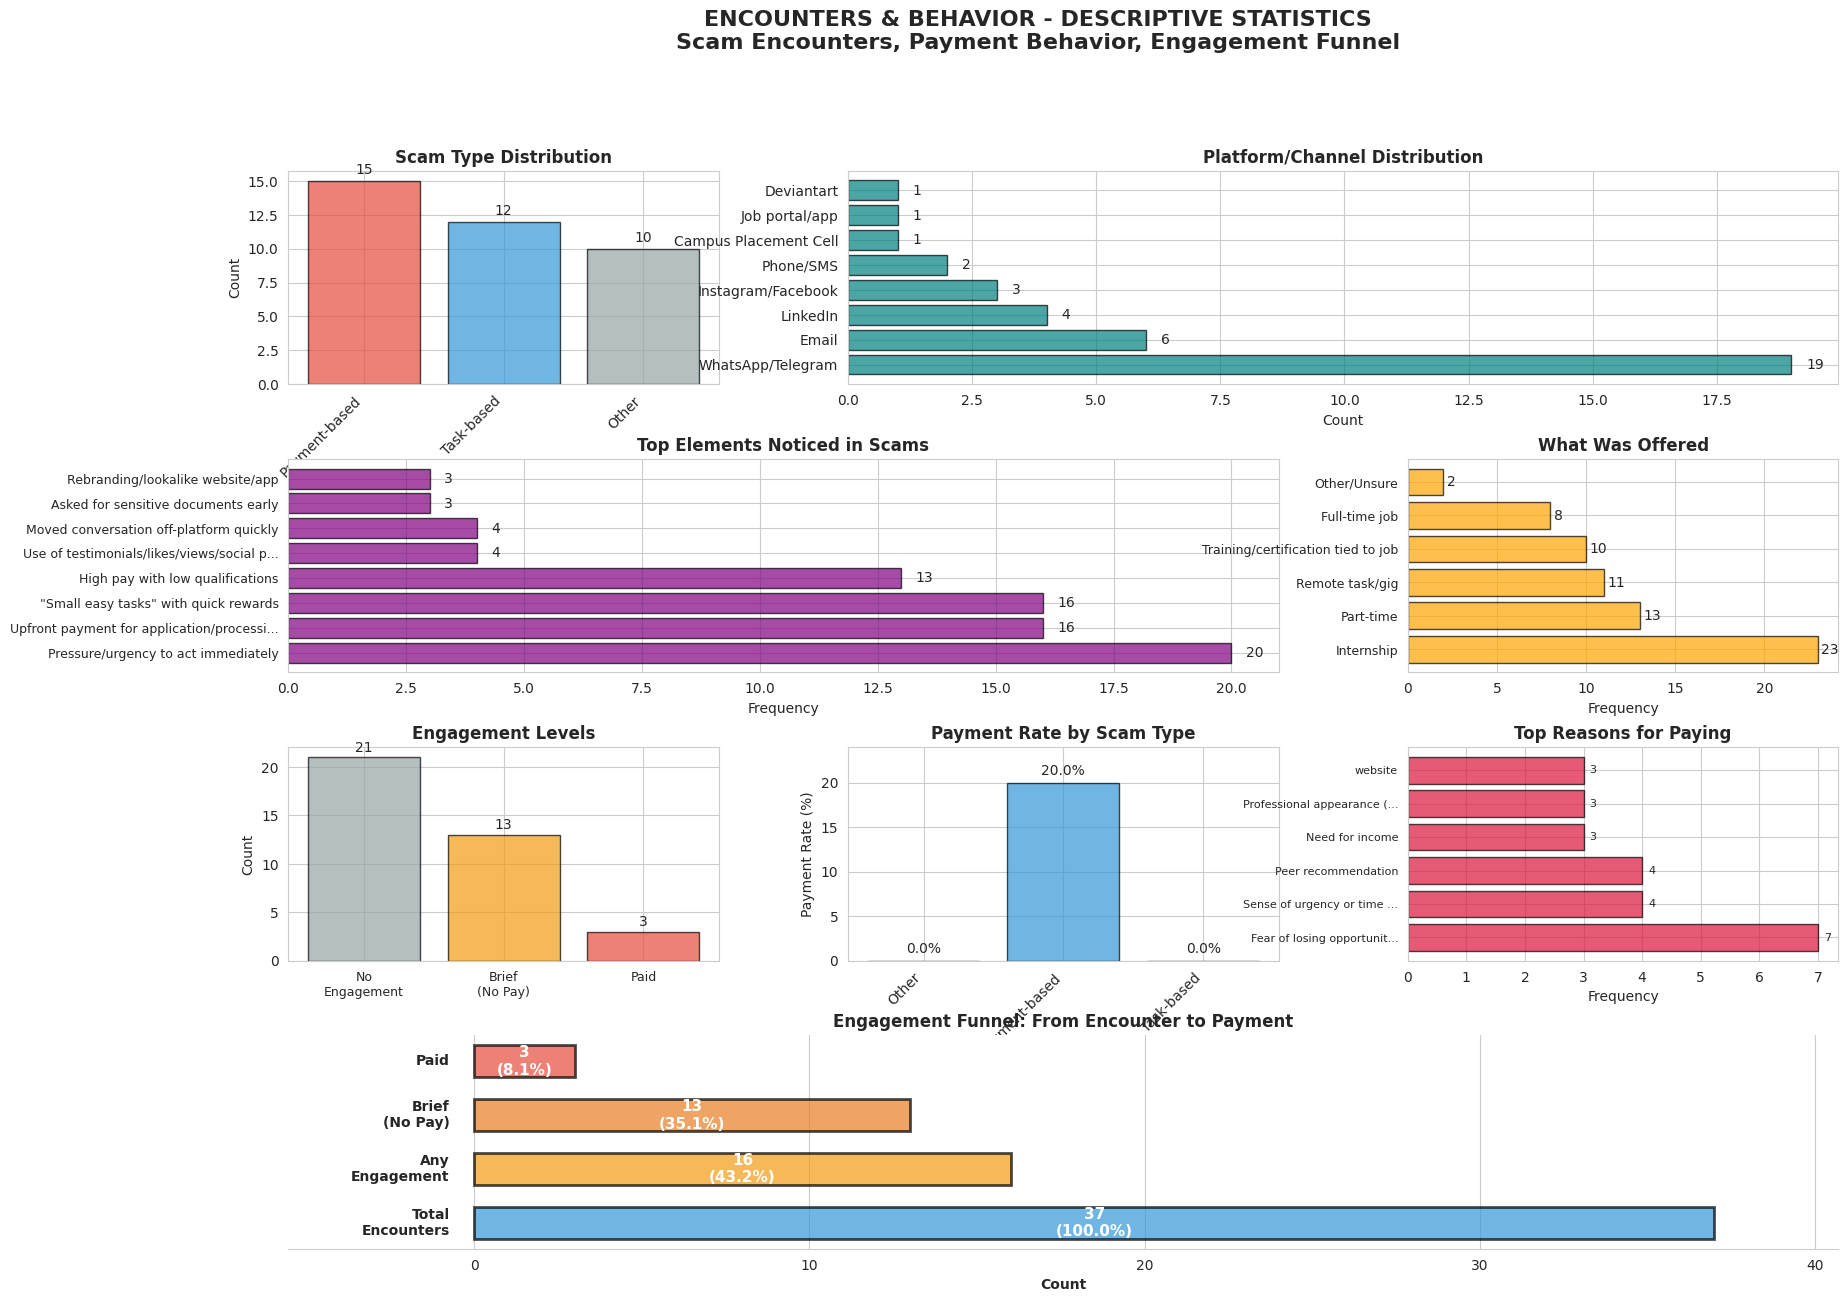

In [2]:
"""
GROUP 2: ENCOUNTERS & BEHAVIOR - DESCRIPTIVE STATISTICS
Scam Encounters, Payment Behavior, Engagement Funnel

Pure descriptive - frequencies, percentages, distributions
NO hypothesis testing, NO p-values
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (18, 12)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_excel('responses.xlsx')

print("="*80)
print("GROUP 2: ENCOUNTERS & BEHAVIOR - DESCRIPTIVE STATISTICS")
print("="*80)

# Filter to those with encounters
encounter_col = 'Did you engage with it at all?'
encounters = df[df[encounter_col].notna()].copy()
n_encounters = len(encounters)

print(f"\nAnalyzing encounters subset: n={n_encounters}")

# ============================================================================
# 4. SCAM ENCOUNTERS
# ============================================================================

print("\n" + "="*80)
print("4. SCAM ENCOUNTERS")
print("="*80)

# Scam type
scam_type_col = 'Which BEST describes this encounter?'
print(f"\nScam Type Distribution (n={encounters[scam_type_col].notna().sum()}):")
scam_types = encounters[scam_type_col].value_counts()
for scam_type, count in scam_types.items():
    pct = count / encounters[scam_type_col].notna().sum() * 100
    # Shorten for display
    short_type = scam_type[:60] + "..." if len(scam_type) > 60 else scam_type
    print(f"  {short_type}: {count} ({pct:.1f}%)")

# Simplified categories
encounters['scam_category'] = 'Other'
encounters.loc[encounters[scam_type_col].str.contains('Payment-based', na=False), 'scam_category'] = 'Payment-based'
encounters.loc[encounters[scam_type_col].str.contains('Task-based', na=False), 'scam_category'] = 'Task-based'

print(f"\nSimplified Categories:")
simple_cats = encounters['scam_category'].value_counts()
for cat, count in simple_cats.items():
    pct = count / len(encounters) * 100
    print(f"  {cat}: {count} ({pct:.1f}%)")

# Platform/Channel
platform_col = 'How did the opportunity first reach you?'
print(f"\nPlatform/Channel Distribution (n={encounters[platform_col].notna().sum()}):")
platforms = encounters[platform_col].value_counts()
for platform, count in platforms.items():
    pct = count / encounters[platform_col].notna().sum() * 100
    print(f"  {platform}: {count} ({pct:.1f}%)")

# What was offered
offered_col = 'What was being offered? (select all that apply)'
print(f"\nWhat Was Offered (n={encounters[offered_col].notna().sum()}):")
all_offered = []
for item in encounters[offered_col].dropna():
    if isinstance(item, str):
        all_offered.extend([o.strip() for o in item.split(',')])
offered_counter = Counter(all_offered)
total_offer_responses = encounters[offered_col].notna().sum()
for offer, count in offered_counter.most_common():
    pct = count / total_offer_responses * 100
    print(f"  {offer}: {count} ({pct:.1f}%)")

# Elements noticed
elements_col = 'Which elements did you notice? (select all that apply)'
print(f"\nElements Noticed (n={encounters[elements_col].notna().sum()}):")
all_elements = []
for item in encounters[elements_col].dropna():
    if isinstance(item, str):
        all_elements.extend([e.strip() for e in item.split(',')])
elements_counter = Counter(all_elements)
total_elem_responses = encounters[elements_col].notna().sum()
for element, count in elements_counter.most_common():
    pct = count / total_elem_responses * 100
    # Shorten long elements
    short_elem = element[:70] + "..." if len(element) > 70 else element
    print(f"  {short_elem}: {count} ({pct:.1f}%)")

# Engagement level
print(f"\nEngagement Level (n={n_encounters}):")
engagement_dist = encounters[encounter_col].value_counts()
for level, count in engagement_dist.items():
    pct = count / n_encounters * 100
    print(f"  {level}: {count} ({pct:.1f}%)")

# ============================================================================
# 5. PAYMENT BEHAVIOR
# ============================================================================

print("\n" + "="*80)
print("5. PAYMENT BEHAVIOR")
print("="*80)

# Payment status from engagement
encounters['made_payment'] = (encounters[encounter_col] == 'Yes, including payment').astype(int)
payers = encounters[encounters['made_payment'] == 1]
non_payers = encounters[encounters['made_payment'] == 0]

print(f"\nPayment Status:")
print(f"  Paid: {len(payers)} ({len(payers)/n_encounters*100:.1f}%)")
print(f"  Did not pay: {len(non_payers)} ({len(non_payers)/n_encounters*100:.1f}%)")

# Payment amounts (combine both columns)
payment_amount_col1 = 'Total amount paid (approx.)'
payment_amount_col2 = 'Total amount paid (if any)'

print(f"\nPayment Amounts (among those who paid or provided amount):")
# Combine payment data
all_payment_amounts = pd.concat([
    encounters[payment_amount_col1],
    encounters[payment_amount_col2]
]).dropna()
all_payment_amounts = all_payment_amounts[all_payment_amounts != 'I did not pay']

if len(all_payment_amounts) > 0:
    payment_amounts_dist = all_payment_amounts.value_counts()
    for amount, count in payment_amounts_dist.items():
        pct = count / len(all_payment_amounts) * 100
        print(f"  {amount}: {count} ({pct:.1f}%)")
else:
    print("  No payment amounts reported")

# First payment amount
first_payment_col = 'What was the first payment amount requested? (in ₹)'
if first_payment_col in encounters.columns:
    first_payments = encounters[first_payment_col].dropna()
    if len(first_payments) > 0:
        print(f"\nFirst Payment Amounts Requested (n={len(first_payments)}):")
        print(f"  Sample values: {first_payments.head(10).tolist()}")

# Number of payments made
num_payments_col = 'How many payments did you make in total?'
if num_payments_col in encounters.columns:
    num_payments = encounters[num_payments_col].dropna()
    if len(num_payments) > 0:
        print(f"\nNumber of Payments Made (n={len(num_payments)}):")
        num_payments_dist = num_payments.value_counts()
        for num, count in num_payments_dist.items():
            pct = count / len(num_payments) * 100
            print(f"  {num} payment(s): {count} ({pct:.1f}%)")

# Payment methods
payment_methods_col1 = 'Payment methods used (select all that apply)'
payment_methods_col2 = 'Payment methods used (select all that apply).1'

all_methods = []
for col in [payment_methods_col1, payment_methods_col2]:
    if col in encounters.columns:
        for item in encounters[col].dropna():
            if isinstance(item, str):
                all_methods.extend([m.strip() for m in item.split(',')])

if len(all_methods) > 0:
    print(f"\nPayment Methods Used:")
    methods_counter = Counter(all_methods)
    for method, count in methods_counter.most_common():
        print(f"  {method}: {count}")

# Reasons for paying
reasons_col1 = 'What affected you to pay at the time? (only if applied, select all top reasons)'
reasons_col2 = 'What affected you to pay at the time? (only if applied, select all top reasons).1'

all_reasons = []
for col in [reasons_col1, reasons_col2]:
    if col in encounters.columns:
        for item in encounters[col].dropna():
            if isinstance(item, str):
                all_reasons.extend([r.strip() for r in item.split(',')])

if len(all_reasons) > 0:
    print(f"\nReasons for Paying:")
    reasons_counter = Counter(all_reasons)
    for reason, count in reasons_counter.most_common():
        pct = count / len(all_reasons) * 100
        print(f"  {reason}: {count} ({pct:.1f}% of all reasons cited)")

# Payment by scam type
print(f"\nPayment Rate by Scam Type:")
payment_by_type = encounters.groupby('scam_category')['made_payment'].agg(['sum', 'count', 'mean'])
for scam_type, row in payment_by_type.iterrows():
    pct = row['mean'] * 100
    print(f"  {scam_type}: {int(row['sum'])}/{int(row['count'])} paid ({pct:.1f}%)")

# ============================================================================
# 6. ENGAGEMENT FUNNEL
# ============================================================================

print("\n" + "="*80)
print("6. ENGAGEMENT FUNNEL")
print("="*80)

# Calculate funnel stages
total_encounters = n_encounters
no_engagement = (encounters[encounter_col] == 'No').sum()
brief_engagement = (encounters[encounter_col] == 'Yes, briefly (no payment)').sum()
paid = (encounters[encounter_col] == 'Yes, including payment').sum()
any_engagement = brief_engagement + paid

print(f"\nFunnel Stages:")
print(f"  1. Total Encounters: {total_encounters} (100.0%)")
print(f"  2. Any Engagement: {any_engagement} ({any_engagement/total_encounters*100:.1f}%)")
print(f"     - Brief (no pay): {brief_engagement} ({brief_engagement/total_encounters*100:.1f}%)")
print(f"     - Paid: {paid} ({paid/total_encounters*100:.1f}%)")
print(f"  3. No Engagement: {no_engagement} ({no_engagement/total_encounters*100:.1f}%)")

print(f"\nConversion Rates:")
print(f"  Encounter → Any Engagement: {any_engagement/total_encounters*100:.1f}%")
print(f"  Encounter → Payment: {paid/total_encounters*100:.1f}%")
if any_engagement > 0:
    print(f"  Engagement → Payment: {paid/any_engagement*100:.1f}%")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# Row 1: Scam types and platforms
ax1 = fig.add_subplot(gs[0, 0])
simple_cats_plot = encounters['scam_category'].value_counts()
colors_scam = {'Payment-based': '#e74c3c', 'Task-based': '#3498db', 'Other': '#95a5a6'}
bar_colors = [colors_scam.get(cat, '#95a5a6') for cat in simple_cats_plot.index]
ax1.bar(range(len(simple_cats_plot)), simple_cats_plot.values, color=bar_colors, alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(simple_cats_plot)))
ax1.set_xticklabels(simple_cats_plot.index, rotation=45, ha='right')
ax1.set_ylabel('Count')
ax1.set_title('Scam Type Distribution', fontweight='bold')
for i, count in enumerate(simple_cats_plot.values):
    ax1.text(i, count + 0.3, str(count), ha='center', va='bottom')

ax2 = fig.add_subplot(gs[0, 1:])
platforms_plot = encounters[platform_col].value_counts().head(8)
ax2.barh(range(len(platforms_plot)), platforms_plot.values, color='teal', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(platforms_plot)))
ax2.set_yticklabels(platforms_plot.index)
ax2.set_xlabel('Count')
ax2.set_title('Platform/Channel Distribution', fontweight='bold')
for i, count in enumerate(platforms_plot.values):
    ax2.text(count + 0.3, i, str(count), va='center')

# Row 2: What was offered and elements noticed
ax3 = fig.add_subplot(gs[1, 0:2])
elements_plot = pd.Series(dict(elements_counter.most_common(8)))
# Shorten labels
short_labels = [elem[:40] + "..." if len(elem) > 40 else elem for elem in elements_plot.index]
ax3.barh(range(len(elements_plot)), elements_plot.values, color='purple', alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(elements_plot)))
ax3.set_yticklabels(short_labels, fontsize=9)
ax3.set_xlabel('Frequency')
ax3.set_title('Top Elements Noticed in Scams', fontweight='bold')
for i, count in enumerate(elements_plot.values):
    ax3.text(count + 0.3, i, str(count), va='center')

ax4 = fig.add_subplot(gs[1, 2])
offered_plot = pd.Series(dict(offered_counter.most_common(6)))
ax4.barh(range(len(offered_plot)), offered_plot.values, color='orange', alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(offered_plot)))
ax4.set_yticklabels(offered_plot.index, fontsize=9)
ax4.set_xlabel('Frequency')
ax4.set_title('What Was Offered', fontweight='bold')
for i, count in enumerate(offered_plot.values):
    ax4.text(count + 0.2, i, str(count), va='center')

# Row 3: Engagement and Payment
ax5 = fig.add_subplot(gs[2, 0])
engagement_levels = encounters[encounter_col].value_counts()
colors_engage = {'No': '#95a5a6', 'Yes, briefly (no payment)': '#f39c12', 'Yes, including payment': '#e74c3c'}
bar_colors_engage = [colors_engage.get(level, '#95a5a6') for level in engagement_levels.index]
ax5.bar(range(len(engagement_levels)), engagement_levels.values, color=bar_colors_engage, alpha=0.7, edgecolor='black')
ax5.set_xticks(range(len(engagement_levels)))
ax5.set_xticklabels(['No\nEngagement', 'Brief\n(No Pay)', 'Paid'], fontsize=9)
ax5.set_ylabel('Count')
ax5.set_title('Engagement Levels', fontweight='bold')
for i, count in enumerate(engagement_levels.values):
    ax5.text(i, count + 0.3, str(count), ha='center', va='bottom')

ax6 = fig.add_subplot(gs[2, 1])
# Payment by scam type
payment_by_type_plot = encounters.groupby('scam_category')['made_payment'].mean() * 100
ax6.bar(range(len(payment_by_type_plot)), payment_by_type_plot.values, 
        color=['#e74c3c', '#3498db', '#95a5a6'][:len(payment_by_type_plot)], alpha=0.7, edgecolor='black')
ax6.set_xticks(range(len(payment_by_type_plot)))
ax6.set_xticklabels(payment_by_type_plot.index, rotation=45, ha='right')
ax6.set_ylabel('Payment Rate (%)')
ax6.set_ylim([0, max(payment_by_type_plot.values) * 1.2 if len(payment_by_type_plot) > 0 else 10])
ax6.set_title('Payment Rate by Scam Type', fontweight='bold')
for i, pct in enumerate(payment_by_type_plot.values):
    ax6.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom')

# Reasons for paying
ax7 = fig.add_subplot(gs[2, 2])
if len(all_reasons) > 0:
    reasons_plot = pd.Series(dict(reasons_counter.most_common(6)))
    # Shorten labels
    short_reasons = [r[:25] + "..." if len(r) > 25 else r for r in reasons_plot.index]
    ax7.barh(range(len(reasons_plot)), reasons_plot.values, color='crimson', alpha=0.7, edgecolor='black')
    ax7.set_yticks(range(len(reasons_plot)))
    ax7.set_yticklabels(short_reasons, fontsize=8)
    ax7.set_xlabel('Frequency')
    ax7.set_title('Top Reasons for Paying', fontweight='bold')
    for i, count in enumerate(reasons_plot.values):
        ax7.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax7.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax7.transAxes)
    ax7.set_title('Top Reasons for Paying', fontweight='bold')

# Row 4: Engagement funnel
ax8 = fig.add_subplot(gs[3, :])
funnel_data = {
    'Total\nEncounters': total_encounters,
    'Any\nEngagement': any_engagement,
    'Brief\n(No Pay)': brief_engagement,
    'Paid': paid
}
funnel_values = list(funnel_data.values())
funnel_labels = list(funnel_data.keys())
funnel_colors = ['#3498db', '#f39c12', '#e67e22', '#e74c3c']

# Funnel chart (decreasing bar widths)
y_pos = range(len(funnel_values))
max_width = max(funnel_values)
for i, (label, value, color) in enumerate(zip(funnel_labels, funnel_values, funnel_colors)):
    width = value / max_width
    ax8.barh(i, value, height=0.6, color=color, alpha=0.7, edgecolor='black', linewidth=2)
    
    # Percentage of total
    pct = value / total_encounters * 100
    ax8.text(value/2, i, f'{value}\n({pct:.1f}%)', ha='center', va='center', 
             fontweight='bold', fontsize=11, color='white')
    
    # Label on left
    ax8.text(-max_width*0.02, i, label, ha='right', va='center', fontweight='bold', fontsize=10)

ax8.set_yticks([])
ax8.set_xlim([-max_width*0.15, max_width*1.1])
ax8.set_xlabel('Count', fontweight='bold')
ax8.set_title('Engagement Funnel: From Encounter to Payment', fontweight='bold', fontsize=12)
ax8.spines['left'].set_visible(False)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)

plt.suptitle('ENCOUNTERS & BEHAVIOR - DESCRIPTIVE STATISTICS\nScam Encounters, Payment Behavior, Engagement Funnel',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('group2_descriptive_stats.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: group2_descriptive_stats.png")

print("\n" + "="*80)
print("GROUP 2 ANALYSIS COMPLETE")
print("="*80)
print("\nKey Takeaways:")
print(f"  • Most common platform: {platforms.index[0] if len(platforms) > 0 else 'N/A'} (n={platforms.values[0] if len(platforms) > 0 else 0})")
print(f"  • Payment rate: {paid}/{total_encounters} ({paid/total_encounters*100:.1f}%)")
print(f"  • Engagement rate: {any_engagement}/{total_encounters} ({any_engagement/total_encounters*100:.1f}%)")
print(f"  • Most common element: {elements_counter.most_common(1)[0][0][:50] if len(elements_counter) > 0 else 'N/A'}")
if len(all_reasons) > 0:
    print(f"  • Top reason for paying: {reasons_counter.most_common(1)[0][0]}")
print(f"  • Scam type breakdown: {dict(simple_cats)}")

GROUP 3: INFLUENCES & TACTICS - DESCRIPTIVE STATISTICS

Analyzing encounters subset: n=37

7. PSYCHOLOGICAL INFLUENCE FACTORS

Social Proof Influence (n=37):
  1/5: 12 (32.4%)
  2/5: 8 (21.6%)
  3/5: 8 (21.6%)
  4/5: 8 (21.6%)
  5/5: 1 (2.7%)
  Mean: 2.41, Median: 2.0

Sunk Cost Influence (n=37):
  1/5: 12 (32.4%)
  2/5: 10 (27.0%)
  3/5: 11 (29.7%)
  4/5: 3 (8.1%)
  5/5: 1 (2.7%)
  Mean: 2.22, Median: 2.0

Emotional Responses (after experience):

Anger (n=36):
  1/5: 6 (16.7%)
  2/5: 7 (19.4%)
  3/5: 8 (22.2%)
  4/5: 6 (16.7%)
  5/5: 9 (25.0%)
  Mean: 3.14, Median: 3.0

Anxiety (n=35):
  1/5: 16 (45.7%)
  2/5: 7 (20.0%)
  3/5: 4 (11.4%)
  4/5: 6 (17.1%)
  5/5: 2 (5.7%)
  Mean: 2.17, Median: 2.0

Embarrassment (n=35):
  1/5: 19 (54.3%)
  2/5: 4 (11.4%)
  3/5: 5 (14.3%)
  4/5: 2 (5.7%)
  5/5: 5 (14.3%)
  Mean: 2.14, Median: 1.0

Reasons for Paying (cleaned, n=34 total mentions):
  Fear of losing opportunity: 7 (20.6%)
  Sense of urgency or time pressure influence: 4 (11.8%)
  Peer recom

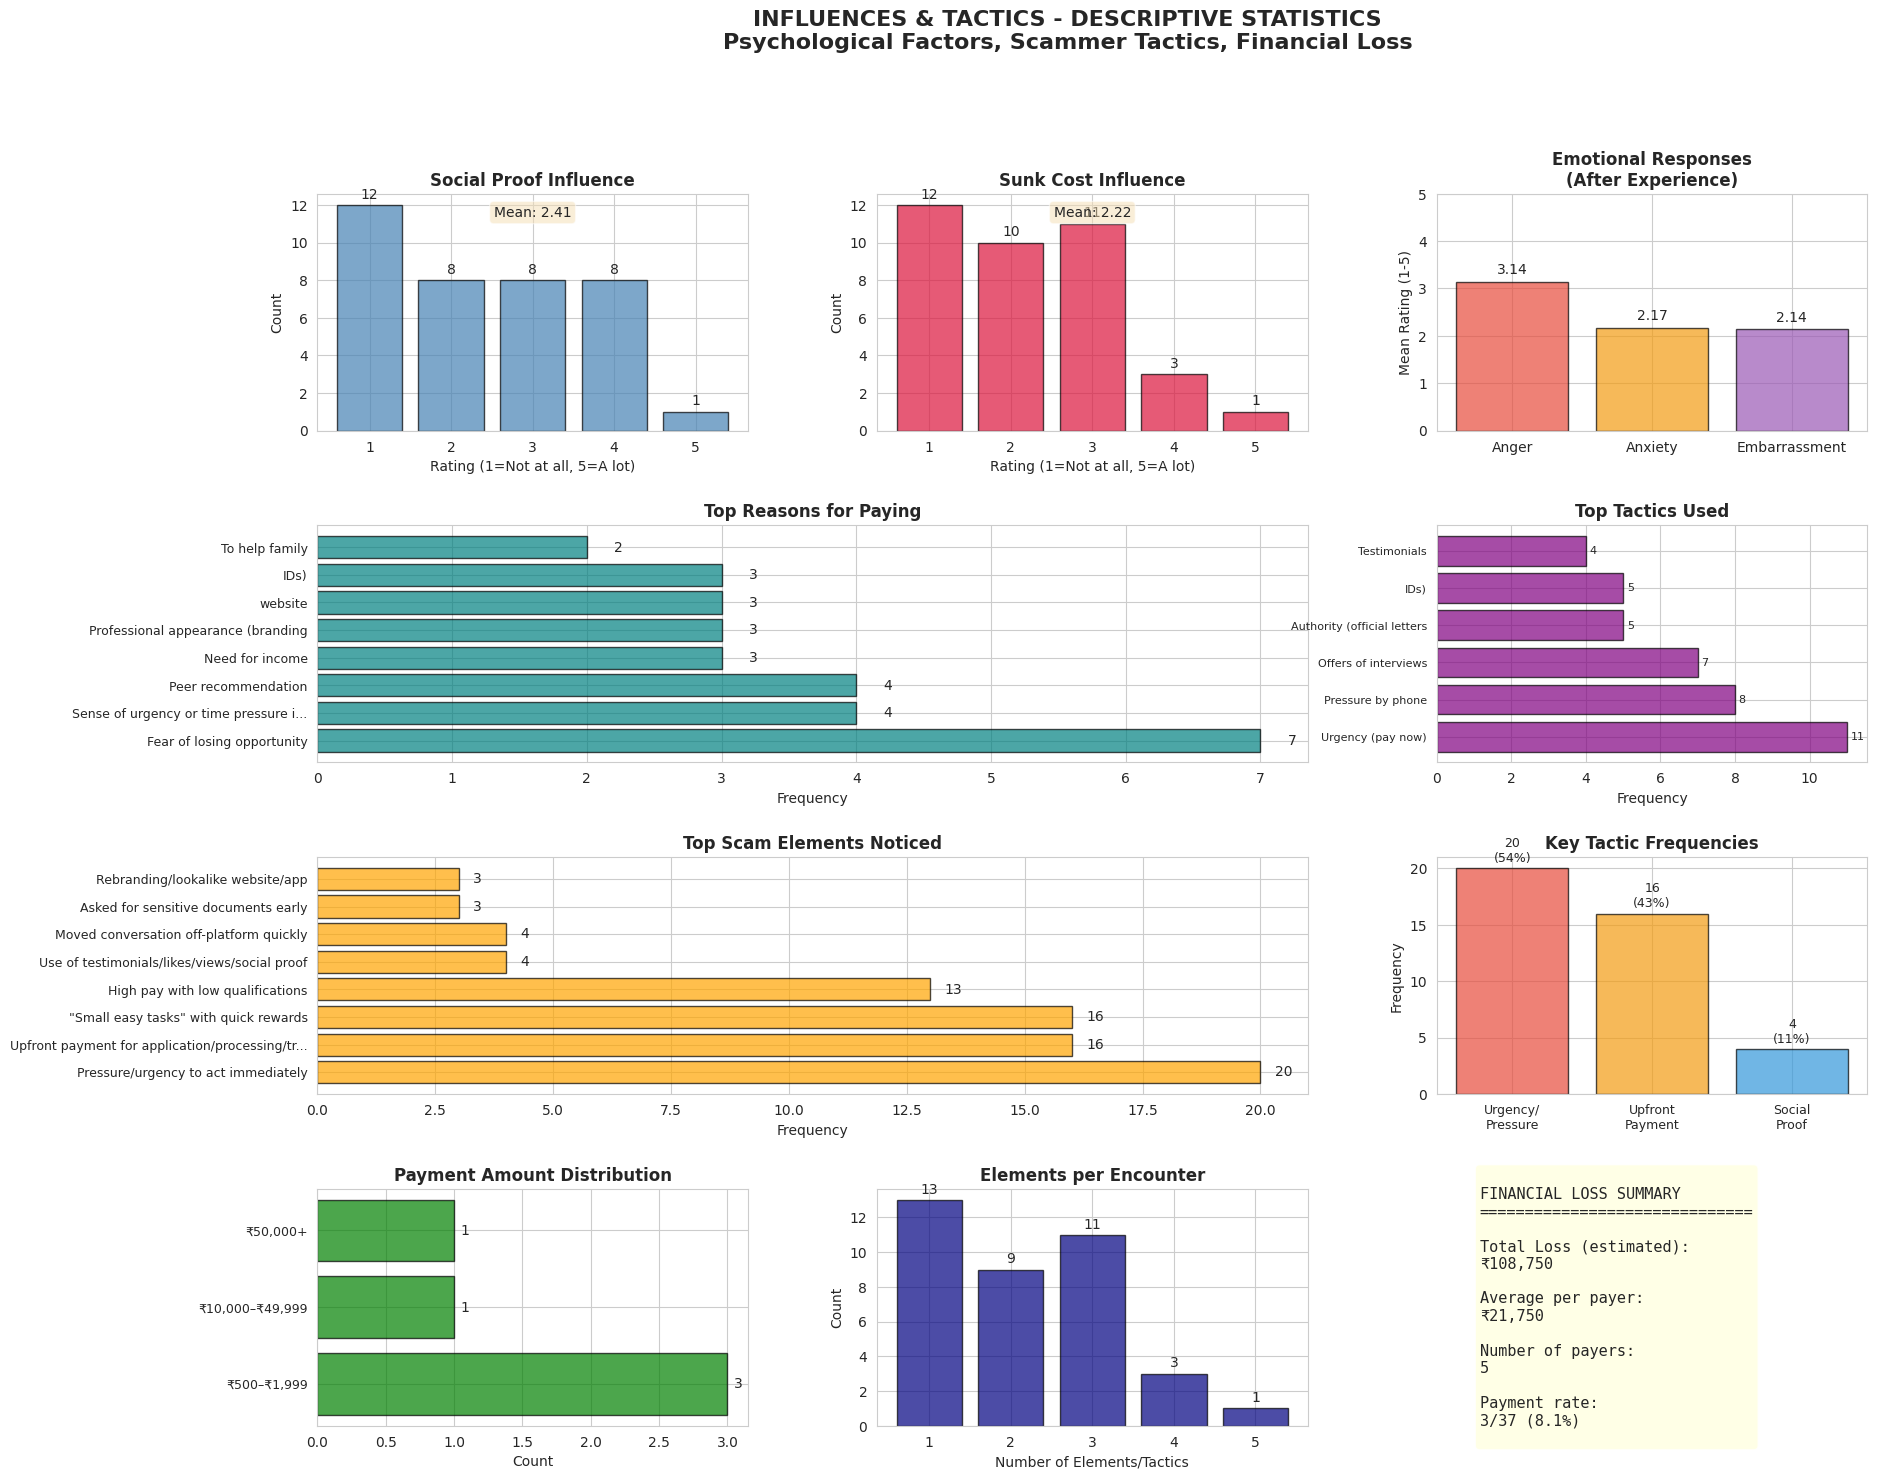

In [3]:
"""
GROUP 3: INFLUENCES & TACTICS - DESCRIPTIVE STATISTICS
Psychological Influence Factors, Tactics Used by Scammers, Financial Loss Analysis

Pure descriptive - frequencies, percentages, distributions
NO hypothesis testing, NO p-values
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (18, 14)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_excel('responses.xlsx')

print("="*80)
print("GROUP 3: INFLUENCES & TACTICS - DESCRIPTIVE STATISTICS")
print("="*80)

# Filter to those with encounters
encounter_col = 'Did you engage with it at all?'
encounters = df[df[encounter_col].notna()].copy()
n_encounters = len(encounters)

print(f"\nAnalyzing encounters subset: n={n_encounters}")

# ============================================================================
# 7. PSYCHOLOGICAL INFLUENCE FACTORS
# ============================================================================

print("\n" + "="*80)
print("7. PSYCHOLOGICAL INFLUENCE FACTORS")
print("="*80)

# Social proof influence
social_proof_col = 'How much did social proof (likes/testimonials) influence your decision to continue?'
print(f"\nSocial Proof Influence (n={encounters[social_proof_col].notna().sum()}):")
social_proof_dist = encounters[social_proof_col].value_counts().sort_index()
for rating, count in social_proof_dist.items():
    pct = count / encounters[social_proof_col].notna().sum() * 100
    print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
mean_social = encounters[social_proof_col].mean()
median_social = encounters[social_proof_col].median()
print(f"  Mean: {mean_social:.2f}, Median: {median_social:.1f}")

# Sunk cost influence
sunk_cost_col = 'How much did the time and effort you had already invested influence your decision to continue?'
print(f"\nSunk Cost Influence (n={encounters[sunk_cost_col].notna().sum()}):")
sunk_cost_dist = encounters[sunk_cost_col].value_counts().sort_index()
for rating, count in sunk_cost_dist.items():
    pct = count / encounters[sunk_cost_col].notna().sum() * 100
    print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
mean_sunk = encounters[sunk_cost_col].mean()
median_sunk = encounters[sunk_cost_col].median()
print(f"  Mean: {mean_sunk:.2f}, Median: {median_sunk:.1f}")

# Emotional responses
anger_col = 'After this experience, how much did you feel: Anger'
anxiety_col = 'After this experience, how much did you feel: Anxiety'
embarrassment_col = 'After this experience, how much did you feel: Embarrassment'

emotional_cols = {
    'Anger': anger_col,
    'Anxiety': anxiety_col,
    'Embarrassment': embarrassment_col
}

print(f"\nEmotional Responses (after experience):")
for emotion, col in emotional_cols.items():
    if col in encounters.columns:
        print(f"\n{emotion} (n={encounters[col].notna().sum()}):")
        emotion_dist = encounters[col].value_counts().sort_index()
        for rating, count in emotion_dist.items():
            pct = count / encounters[col].notna().sum() * 100
            print(f"  {int(rating)}/5: {count} ({pct:.1f}%)")
        mean_emotion = encounters[col].mean()
        median_emotion = encounters[col].median()
        print(f"  Mean: {mean_emotion:.2f}, Median: {median_emotion:.1f}")

# Reasons for paying (detailed breakdown)
reasons_col1 = 'What affected you to pay at the time? (only if applied, select all top reasons)'
reasons_col2 = 'What affected you to pay at the time? (only if applied, select all top reasons).1'

all_reasons = []
for col in [reasons_col1, reasons_col2]:
    if col in encounters.columns:
        for item in encounters[col].dropna():
            if isinstance(item, str):
                all_reasons.extend([r.strip() for r in item.split(',')])

# Clean up reasons (remove "didn't pay" variants)
cleaned_reasons = [r for r in all_reasons if not any(x in r.lower() for x in ['didn\'t pay', 'did not pay', 'not paid', 'i didn\'t', 'i did not'])]

if len(cleaned_reasons) > 0:
    print(f"\nReasons for Paying (cleaned, n={len(cleaned_reasons)} total mentions):")
    reasons_counter = Counter(cleaned_reasons)
    for reason, count in reasons_counter.most_common():
        pct = count / len(cleaned_reasons) * 100
        print(f"  {reason}: {count} ({pct:.1f}%)")

# ============================================================================
# 8. TACTICS USED BY SCAMMERS
# ============================================================================

print("\n" + "="*80)
print("8. TACTICS USED BY SCAMMERS")
print("="*80)

# Tactics from multiple columns
tactics_col = 'Which tactics were used? (select all that apply)'

all_tactics = []
if tactics_col in encounters.columns:
    for item in encounters[tactics_col].dropna():
        if isinstance(item, str):
            all_tactics.extend([t.strip() for t in item.split(',')])

if len(all_tactics) > 0:
    print(f"\nTactics Used (n={len(all_tactics)} total mentions):")
    tactics_counter = Counter(all_tactics)
    for tactic, count in tactics_counter.most_common():
        pct = count / len(all_tactics) * 100
        print(f"  {tactic}: {count} ({pct:.1f}%)")

# Elements noticed (already analyzed but relevant for tactics)
elements_col = 'Which elements did you notice? (select all that apply)'
all_elements = []
for item in encounters[elements_col].dropna():
    if isinstance(item, str):
        all_elements.extend([e.strip() for e in item.split(',')])

print(f"\nScam Elements (tactics perspective, n={len(all_elements)} total mentions):")
elements_counter = Counter(all_elements)
for element, count in elements_counter.most_common():
    pct = count / len(all_elements) * 100
    short_elem = element[:60] + "..." if len(element) > 60 else element
    print(f"  {short_elem}: {count} ({pct:.1f}%)")

# Urgency/pressure specifically
urgency_present = sum(1 for elem in all_elements if 'urgency' in elem.lower() or 'pressure' in elem.lower() or 'immediately' in elem.lower())
upfront_payment = sum(1 for elem in all_elements if 'upfront' in elem.lower() or 'payment' in elem.lower())
social_proof_elem = sum(1 for elem in all_elements if 'testimonial' in elem.lower() or 'social proof' in elem.lower())

print(f"\nKey Tactic Frequencies:")
print(f"  Urgency/Pressure tactics: {urgency_present} encounters ({urgency_present/n_encounters*100:.1f}%)")
print(f"  Upfront payment requests: {upfront_payment} encounters ({upfront_payment/n_encounters*100:.1f}%)")
print(f"  Social proof elements: {social_proof_elem} encounters ({social_proof_elem/n_encounters*100:.1f}%)")

# Promises of refunds/guarantees
promises_col = 'Were promises given about refunds, training, or placement guarantees?'
if promises_col in encounters.columns:
    print(f"\nPromises of Refunds/Guarantees (n={encounters[promises_col].notna().sum()}):")
    promises_dist = encounters[promises_col].value_counts().sort_index()
    for rating, count in promises_dist.items():
        pct = count / encounters[promises_col].notna().sum() * 100
        print(f"  {int(rating)}/5 (1=Never, 5=Always): {count} ({pct:.1f}%)")
    mean_promises = encounters[promises_col].mean()
    median_promises = encounters[promises_col].median()
    print(f"  Mean: {mean_promises:.2f}, Median: {median_promises:.1f}")

# Number of tactics per encounter
encounters['num_elements'] = 0
for idx, row in encounters.iterrows():
    if pd.notna(row[elements_col]):
        encounters.loc[idx, 'num_elements'] = len(row[elements_col].split(','))

print(f"\nNumber of Tactics/Elements per Encounter:")
num_tactics_dist = encounters['num_elements'].value_counts().sort_index()
for num, count in num_tactics_dist.items():
    pct = count / len(encounters) * 100
    print(f"  {int(num)} elements: {count} ({pct:.1f}%)")

# ============================================================================
# 9. FINANCIAL LOSS ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("9. FINANCIAL LOSS ANALYSIS")
print("="*80)

# Payment amounts
payment_amount_col1 = 'Total amount paid (approx.)'
payment_amount_col2 = 'Total amount paid (if any)'

# Collect all payment data
all_payments = pd.concat([
    encounters[payment_amount_col1],
    encounters[payment_amount_col2]
]).dropna()
all_payments = all_payments[all_payments != 'I did not pay']

print(f"\nPayment Amount Distribution (n={len(all_payments)}):")
payment_dist = all_payments.value_counts()
for amount, count in payment_dist.items():
    pct = count / len(all_payments) * 100
    print(f"  {amount}: {count} ({pct:.1f}%)")

# Estimate total loss (converting ranges to midpoints)
amount_mapping = {
    'Less than ₹500': 250,
    '₹500–₹1,999': 1250,
    '₹2,000–₹4,999': 3500,
    '₹5,000–₹9,999': 7500,
    '₹10,000–₹49,999': 30000,
    '₹50,000+': 75000  # Conservative estimate
}

total_loss_estimate = 0
for amount, count in payment_dist.items():
    if amount in amount_mapping:
        total_loss_estimate += amount_mapping[amount] * count

print(f"\nEstimated Total Financial Loss:")
print(f"  Total (conservative estimate): ₹{total_loss_estimate:,}")
if len(all_payments) > 0:
    print(f"  Average per payer: ₹{total_loss_estimate/len(all_payments):,.0f}")

# First payment amounts
first_payment_col = 'What was the first payment amount requested? (in ₹)'
if first_payment_col in encounters.columns:
    first_payments = encounters[first_payment_col].dropna()
    # Try to convert to numeric
    numeric_first = []
    for val in first_payments:
        try:
            if isinstance(val, str):
                # Remove commas, 'lakhs', etc
                cleaned = val.replace(',', '').replace('lakhs', '00000').replace('lakh', '00000')
                numeric_first.append(float(cleaned))
            else:
                numeric_first.append(float(val))
        except:
            pass
    
    if len(numeric_first) > 0:
        print(f"\nFirst Payment Amount Statistics (n={len(numeric_first)}):")
        print(f"  Mean: ₹{np.mean(numeric_first):,.0f}")
        print(f"  Median: ₹{np.median(numeric_first):,.0f}")
        print(f"  Min: ₹{np.min(numeric_first):,.0f}")
        print(f"  Max: ₹{np.max(numeric_first):,.0f}")

# Number of payments
num_payments_col = 'How many payments did you make in total?'
if num_payments_col in encounters.columns:
    num_payments = encounters[num_payments_col].dropna()
    # Convert to numeric
    numeric_payments = pd.to_numeric(num_payments, errors='coerce').dropna()
    
    if len(numeric_payments) > 0:
        print(f"\nPayment Frequency (n={len(numeric_payments)}):")
        payment_freq_dist = numeric_payments.value_counts().sort_index()
        for num, count in payment_freq_dist.items():
            pct = count / len(numeric_payments) * 100
            print(f"  {int(num)} payment(s): {count} ({pct:.1f}%)")

# Loss by scam type
encounters['scam_category'] = 'Other'
scam_type_col = 'Which BEST describes this encounter?'
encounters.loc[encounters[scam_type_col].str.contains('Payment-based', na=False), 'scam_category'] = 'Payment-based'
encounters.loc[encounters[scam_type_col].str.contains('Task-based', na=False), 'scam_category'] = 'Task-based'

print(f"\nPayment by Scam Type:")
for scam_type in ['Payment-based', 'Task-based', 'Other']:
    subset = encounters[encounters['scam_category'] == scam_type]
    paid = (subset[encounter_col] == 'Yes, including payment').sum()
    total = len(subset)
    print(f"  {scam_type}: {paid}/{total} paid ({paid/total*100 if total > 0 else 0:.1f}%)")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# Row 1: Psychological influences
ax1 = fig.add_subplot(gs[0, 0])
social_counts = [social_proof_dist.get(float(i), 0) for i in range(1, 6)]
ax1.bar(range(1, 6), social_counts, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Rating (1=Not at all, 5=A lot)')
ax1.set_ylabel('Count')
ax1.set_title('Social Proof Influence', fontweight='bold')
ax1.set_xticks(range(1, 6))
for i, count in enumerate(social_counts, 1):
    if count > 0:
        ax1.text(i, count + 0.2, str(count), ha='center', va='bottom')
ax1.text(0.5, 0.95, f'Mean: {mean_social:.2f}', transform=ax1.transAxes, 
         ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2 = fig.add_subplot(gs[0, 1])
sunk_counts = [sunk_cost_dist.get(float(i), 0) for i in range(1, 6)]
ax2.bar(range(1, 6), sunk_counts, color='crimson', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Rating (1=Not at all, 5=A lot)')
ax2.set_ylabel('Count')
ax2.set_title('Sunk Cost Influence', fontweight='bold')
ax2.set_xticks(range(1, 6))
for i, count in enumerate(sunk_counts, 1):
    if count > 0:
        ax2.text(i, count + 0.2, str(count), ha='center', va='bottom')
ax2.text(0.5, 0.95, f'Mean: {mean_sunk:.2f}', transform=ax2.transAxes,
         ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Emotional responses
ax3 = fig.add_subplot(gs[0, 2])
emotion_means = {}
for emotion, col in emotional_cols.items():
    if col in encounters.columns and encounters[col].notna().sum() > 0:
        emotion_means[emotion] = encounters[col].mean()

if len(emotion_means) > 0:
    ax3.bar(range(len(emotion_means)), emotion_means.values(), 
            color=['#e74c3c', '#f39c12', '#9b59b6'][:len(emotion_means)],
            alpha=0.7, edgecolor='black')
    ax3.set_xticks(range(len(emotion_means)))
    ax3.set_xticklabels(emotion_means.keys())
    ax3.set_ylabel('Mean Rating (1-5)')
    ax3.set_ylim([0, 5])
    ax3.set_title('Emotional Responses\n(After Experience)', fontweight='bold')
    for i, (emotion, value) in enumerate(emotion_means.items()):
        ax3.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

# Row 2: Reasons and Tactics
ax4 = fig.add_subplot(gs[1, :2])
if len(cleaned_reasons) > 0:
    reasons_plot = pd.Series(dict(reasons_counter.most_common(8)))
    short_reasons = [r[:35] + "..." if len(r) > 35 else r for r in reasons_plot.index]
    ax4.barh(range(len(reasons_plot)), reasons_plot.values, color='teal', alpha=0.7, edgecolor='black')
    ax4.set_yticks(range(len(reasons_plot)))
    ax4.set_yticklabels(short_reasons, fontsize=9)
    ax4.set_xlabel('Frequency')
    ax4.set_title('Top Reasons for Paying', fontweight='bold')
    for i, count in enumerate(reasons_plot.values):
        ax4.text(count + 0.2, i, str(count), va='center')
else:
    ax4.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Top Reasons for Paying', fontweight='bold')

ax5 = fig.add_subplot(gs[1, 2])
if len(all_tactics) > 0:
    tactics_plot = pd.Series(dict(tactics_counter.most_common(6)))
    short_tactics = [t[:30] + "..." if len(t) > 30 else t for t in tactics_plot.index]
    ax5.barh(range(len(tactics_plot)), tactics_plot.values, color='purple', alpha=0.7, edgecolor='black')
    ax5.set_yticks(range(len(tactics_plot)))
    ax5.set_yticklabels(short_tactics, fontsize=8)
    ax5.set_xlabel('Frequency')
    ax5.set_title('Top Tactics Used', fontweight='bold')
    for i, count in enumerate(tactics_plot.values):
        ax5.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax5.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Top Tactics Used', fontweight='bold')

# Row 3: Elements and Key tactics
ax6 = fig.add_subplot(gs[2, :2])
elements_plot = pd.Series(dict(elements_counter.most_common(8)))
short_elements = [e[:45] + "..." if len(e) > 45 else e for e in elements_plot.index]
ax6.barh(range(len(elements_plot)), elements_plot.values, color='orange', alpha=0.7, edgecolor='black')
ax6.set_yticks(range(len(elements_plot)))
ax6.set_yticklabels(short_elements, fontsize=9)
ax6.set_xlabel('Frequency')
ax6.set_title('Top Scam Elements Noticed', fontweight='bold')
for i, count in enumerate(elements_plot.values):
    ax6.text(count + 0.3, i, str(count), va='center')

ax7 = fig.add_subplot(gs[2, 2])
key_tactics_data = {
    'Urgency/\nPressure': urgency_present,
    'Upfront\nPayment': upfront_payment,
    'Social\nProof': social_proof_elem
}
ax7.bar(range(len(key_tactics_data)), key_tactics_data.values(),
        color=['#e74c3c', '#f39c12', '#3498db'], alpha=0.7, edgecolor='black')
ax7.set_xticks(range(len(key_tactics_data)))
ax7.set_xticklabels(key_tactics_data.keys(), fontsize=9)
ax7.set_ylabel('Frequency')
ax7.set_title('Key Tactic Frequencies', fontweight='bold')
for i, count in enumerate(key_tactics_data.values()):
    pct = count / n_encounters * 100
    ax7.text(i, count + 0.3, f'{count}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)

# Row 4: Financial loss
ax8 = fig.add_subplot(gs[3, 0])
if len(all_payments) > 0:
    payment_amounts_plot = all_payments.value_counts()
    ax8.barh(range(len(payment_amounts_plot)), payment_amounts_plot.values, 
             color='green', alpha=0.7, edgecolor='black')
    ax8.set_yticks(range(len(payment_amounts_plot)))
    ax8.set_yticklabels(payment_amounts_plot.index, fontsize=9)
    ax8.set_xlabel('Count')
    ax8.set_title('Payment Amount Distribution', fontweight='bold')
    for i, count in enumerate(payment_amounts_plot.values):
        ax8.text(count + 0.05, i, str(count), va='center')
else:
    ax8.text(0.5, 0.5, 'No payment data', ha='center', va='center', transform=ax8.transAxes)
    ax8.set_title('Payment Amount Distribution', fontweight='bold')

ax9 = fig.add_subplot(gs[3, 1])
num_elements_plot = encounters['num_elements'].value_counts().sort_index()
ax9.bar(num_elements_plot.index, num_elements_plot.values, color='navy', alpha=0.7, edgecolor='black')
ax9.set_xlabel('Number of Elements/Tactics')
ax9.set_ylabel('Count')
ax9.set_title('Elements per Encounter', fontweight='bold')
for i, (num, count) in enumerate(num_elements_plot.items()):
    ax9.text(num, count + 0.2, str(count), ha='center', va='bottom')

# Total loss summary
ax10 = fig.add_subplot(gs[3, 2])
ax10.axis('off')
loss_text = f"""
FINANCIAL LOSS SUMMARY
{'='*30}

Total Loss (estimated):
₹{total_loss_estimate:,}

Average per payer:
₹{total_loss_estimate/len(all_payments) if len(all_payments) > 0 else 0:,.0f}

Number of payers:
{len(all_payments)}

Payment rate:
{(encounters[encounter_col] == 'Yes, including payment').sum()}/{n_encounters} ({(encounters[encounter_col] == 'Yes, including payment').sum()/n_encounters*100:.1f}%)
"""
ax10.text(0.1, 0.5, loss_text, fontsize=11, verticalalignment='center',
          family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('INFLUENCES & TACTICS - DESCRIPTIVE STATISTICS\nPsychological Factors, Scammer Tactics, Financial Loss',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('group3_descriptive_stats.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: group3_descriptive_stats.png")

print("\n" + "="*80)
print("GROUP 3 ANALYSIS COMPLETE")
print("="*80)
print("\nKey Takeaways:")
print(f"  • Mean social proof influence: {mean_social:.2f}/5.0")
print(f"  • Mean sunk cost influence: {mean_sunk:.2f}/5.0")
print(f"  • Top reason for paying: {reasons_counter.most_common(1)[0][0] if len(reasons_counter) > 0 else 'N/A'}")
print(f"  • Most common tactic: {elements_counter.most_common(1)[0][0][:50] if len(elements_counter) > 0 else 'N/A'}")
print(f"  • Urgency present: {urgency_present}/{n_encounters} ({urgency_present/n_encounters*100:.1f}%)")
print(f"  • Total estimated loss: ₹{total_loss_estimate:,}")
print(f"  • Average loss per payer: ₹{total_loss_estimate/len(all_payments) if len(all_payments) > 0 else 0:,.0f}")

GROUP 4: OUTCOMES & PATTERNS - DESCRIPTIVE STATISTICS

Analyzing encounters subset: n=37

10. OUTCOMES & CONSEQUENCES

Outcome - Payment-Based Scams (n=15):
  Other: 7 (46.7%)
  I did not get what was promised (suspected fraud): 6 (40.0%)
  Still ongoing/waiting: 1 (6.7%)
  I got partial benefits but not as promised: 1 (6.7%)

Outcome - Task-Based Scams (n=12):
  Other: 5 (41.7%)
  I was asked to pay money and did not receive rewards: 3 (25.0%)
  I received some rewards but not all as promised: 2 (16.7%)
  I did not receive promised rewards (suspected fraud): 2 (16.7%)

Reporting Behavior (n=37):
  No: 34 (91.9%)
  Yes: 3 (8.1%)

Where Reported (n=7 total channels):
  Friends/family: 2
  College/campus office: 2
  National Cyber Crime Helpline/Portal (1930): 2
  Platform/app reporting: 1

Reporting Outcomes (n=2):
  -  account blocked
  - account blocked

11. CROSS-TABULATIONS

--------------------------------------------------------------------------------
CROSS-TAB 1: Payment by Fina

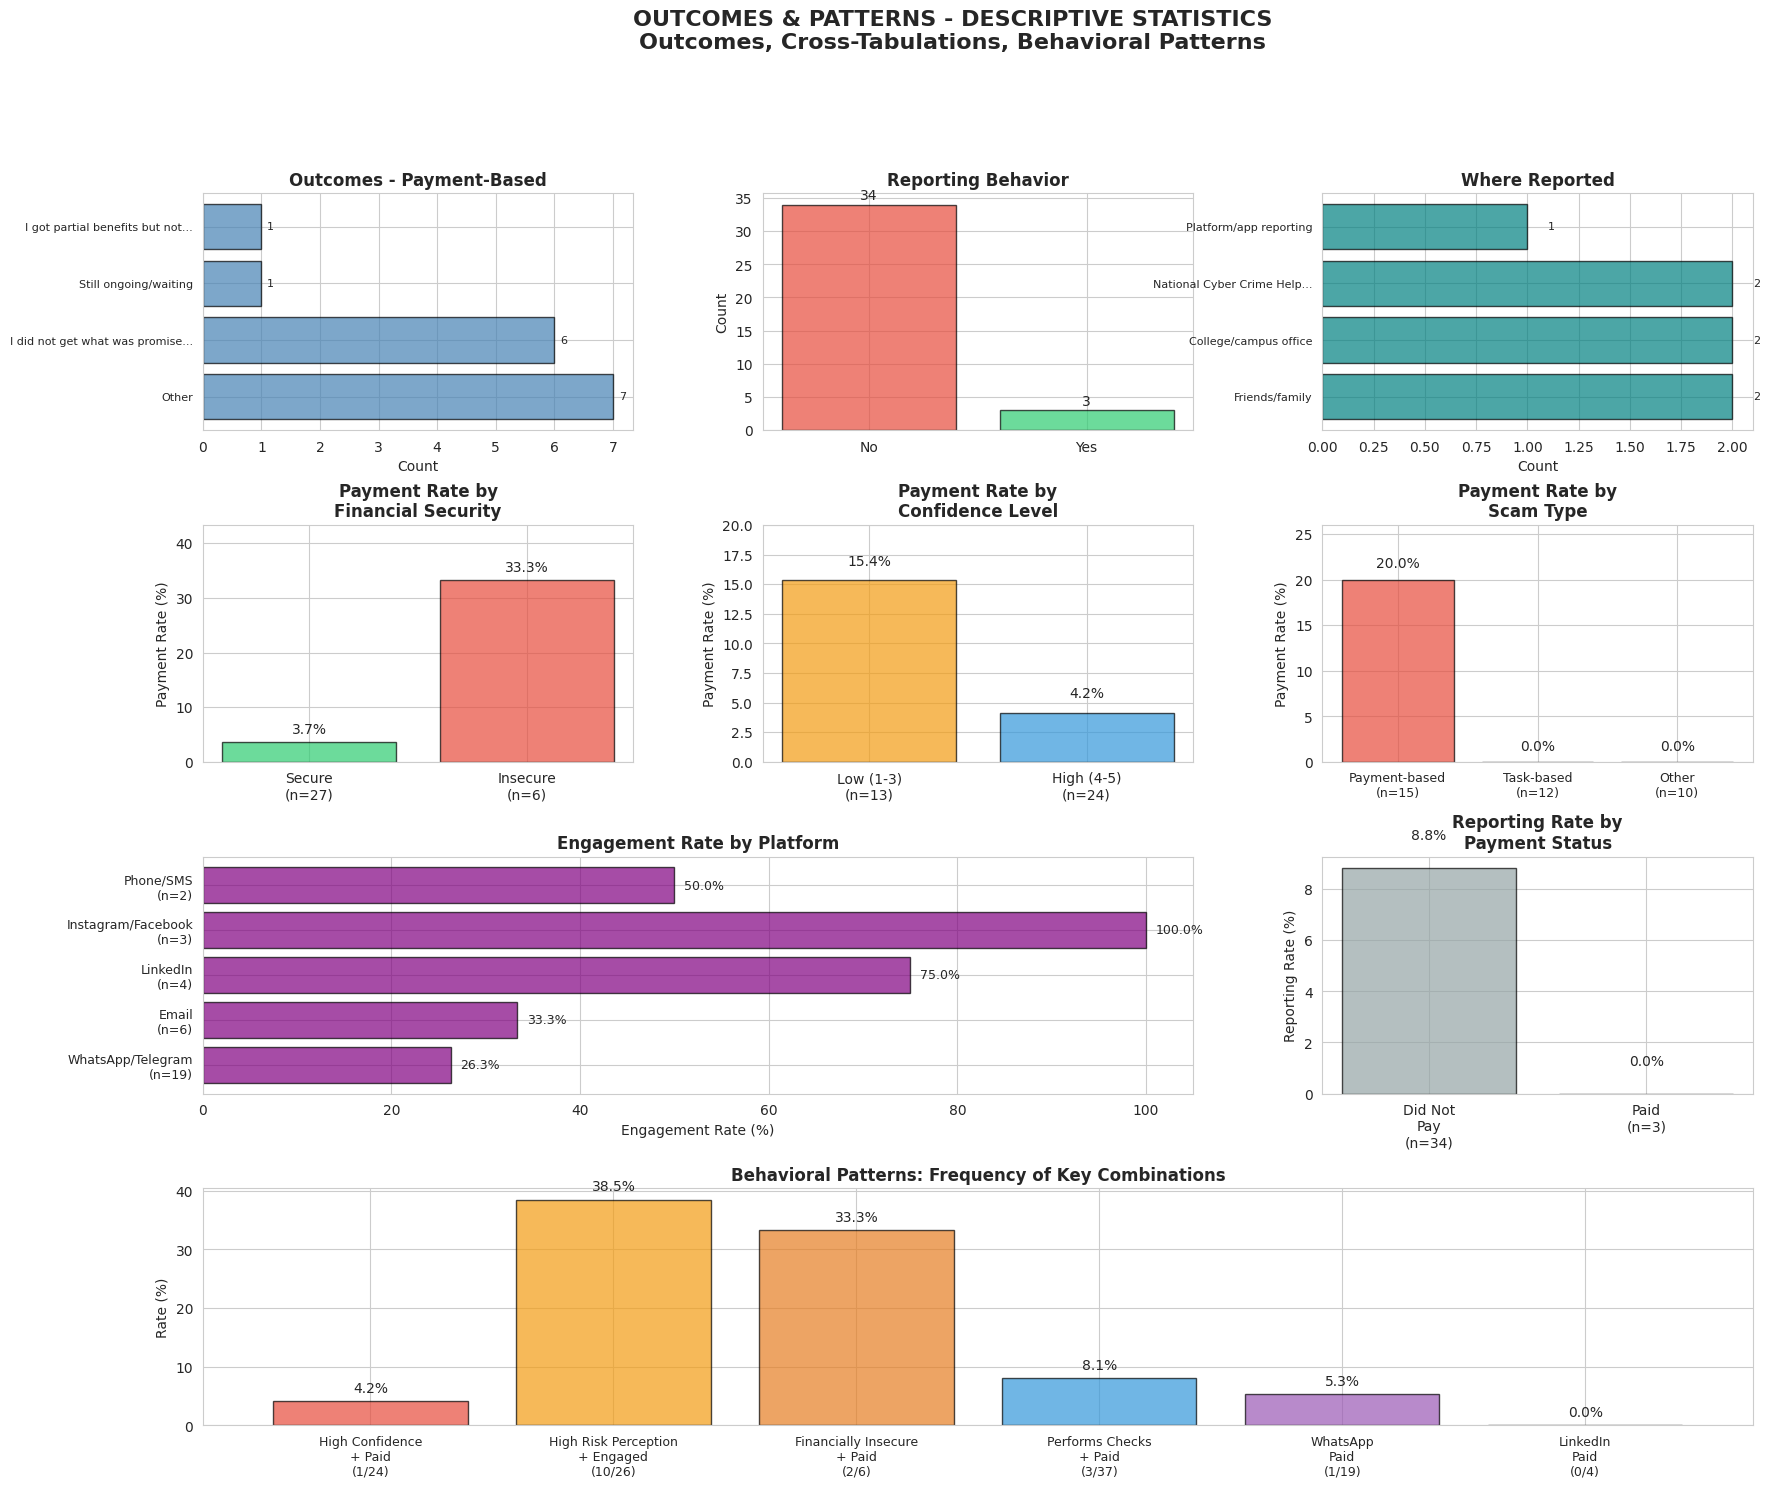

In [4]:
"""
GROUP 4: OUTCOMES & PATTERNS - DESCRIPTIVE STATISTICS
Outcomes & Consequences, Cross-Tabulations, Behavioral Patterns

Pure descriptive - frequencies, percentages, cross-tabs
NO hypothesis testing, NO p-values
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_excel('responses.xlsx')

print("="*80)
print("GROUP 4: OUTCOMES & PATTERNS - DESCRIPTIVE STATISTICS")
print("="*80)

# Filter to those with encounters
encounter_col = 'Did you engage with it at all?'
encounters = df[df[encounter_col].notna()].copy()
n_encounters = len(encounters)

print(f"\nAnalyzing encounters subset: n={n_encounters}")

# ============================================================================
# 10. OUTCOMES & CONSEQUENCES
# ============================================================================

print("\n" + "="*80)
print("10. OUTCOMES & CONSEQUENCES")
print("="*80)

# Outcomes for payment-based
payment_outcome_col = 'What was the outcome of this payment-based opportunity?'
if payment_outcome_col in encounters.columns:
    print(f"\nOutcome - Payment-Based Scams (n={encounters[payment_outcome_col].notna().sum()}):")
    payment_outcomes = encounters[payment_outcome_col].value_counts()
    for outcome, count in payment_outcomes.items():
        pct = count / encounters[payment_outcome_col].notna().sum() * 100
        print(f"  {outcome}: {count} ({pct:.1f}%)")

# Outcomes for task-based
task_outcome_col = 'What was the outcome of this task-based opportunity?'
if task_outcome_col in encounters.columns:
    print(f"\nOutcome - Task-Based Scams (n={encounters[task_outcome_col].notna().sum()}):")
    task_outcomes = encounters[task_outcome_col].value_counts()
    for outcome, count in task_outcomes.items():
        pct = count / encounters[task_outcome_col].notna().sum() * 100
        print(f"  {outcome}: {count} ({pct:.1f}%)")

# Reporting behavior
reporting_col = 'Did you report this experience anywhere?'
print(f"\nReporting Behavior (n={encounters[reporting_col].notna().sum()}):")
reporting_dist = encounters[reporting_col].value_counts()
for response, count in reporting_dist.items():
    pct = count / encounters[reporting_col].notna().sum() * 100
    print(f"  {response}: {count} ({pct:.1f}%)")

# Where reported
where_reported_col = 'Where did you report it? (select all that apply)'
all_report_channels = []
for item in encounters[where_reported_col].dropna():
    if isinstance(item, str):
        all_report_channels.extend([c.strip() for c in item.split(',')])

if len(all_report_channels) > 0:
    print(f"\nWhere Reported (n={len(all_report_channels)} total channels):")
    channel_counter = Counter(all_report_channels)
    for channel, count in channel_counter.most_common():
        print(f"  {channel}: {count}")

# Reporting outcomes
report_outcome_col = 'What was the outcome of your report?'
if report_outcome_col in encounters.columns:
    print(f"\nReporting Outcomes (n={encounters[report_outcome_col].notna().sum()}):")
    for outcome in encounters[report_outcome_col].dropna().head(10):
        print(f"  - {outcome}")

# ============================================================================
# 11. CROSS-TABULATIONS
# ============================================================================

print("\n" + "="*80)
print("11. CROSS-TABULATIONS")
print("="*80)

# Prepare variables
encounters['made_payment'] = (encounters[encounter_col] == 'Yes, including payment').astype(int)

# Financial situation
financial_col = 'Household financial situation'
encounters['financial_situation'] = encounters[financial_col]
financial_map = {
    'In debt': 'Insecure',
    'Struggling (difficulty meeting expenses)': 'Insecure',
    'Manageable (meet expenses)': 'Secure',
    'Comfortable (meet expenses + savings)': 'Secure',
    'Prefer not to say': 'Unknown'
}
encounters['financial_security'] = encounters[financial_col].map(financial_map)

# Confidence
confidence_col = 'How confident are you that you can recognize a job scam when you see one?'
encounters['confidence'] = encounters[confidence_col]
encounters['confidence_group'] = 'Unknown'
encounters.loc[encounters['confidence'] >= 4, 'confidence_group'] = 'High (4-5)'
encounters.loc[encounters['confidence'] <= 3, 'confidence_group'] = 'Low (1-3)'

# Platform
platform_col = 'How did the opportunity first reach you?'
encounters['platform'] = encounters[platform_col]

# Scam type
scam_type_col = 'Which BEST describes this encounter?'
encounters['scam_category'] = 'Other'
encounters.loc[encounters[scam_type_col].str.contains('Payment-based', na=False), 'scam_category'] = 'Payment-based'
encounters.loc[encounters[scam_type_col].str.contains('Task-based', na=False), 'scam_category'] = 'Task-based'

# Cross-tab 1: Payment by Financial Situation
print("\n" + "-"*80)
print("CROSS-TAB 1: Payment by Financial Security")
print("-"*80)
ct1 = pd.crosstab(encounters['financial_security'], encounters['made_payment'], 
                   margins=True, dropna=False)
ct1.columns = ['No Payment', 'Paid', 'Total']
print(ct1)
print("\nPayment Rates:")
for fin_status in ['Secure', 'Insecure', 'Unknown']:
    subset = encounters[encounters['financial_security'] == fin_status]
    if len(subset) > 0:
        paid = subset['made_payment'].sum()
        total = len(subset)
        pct = paid / total * 100
        print(f"  {fin_status}: {paid}/{total} ({pct:.1f}%)")

# Cross-tab 2: Payment by Confidence
print("\n" + "-"*80)
print("CROSS-TAB 2: Payment by Confidence Level")
print("-"*80)
ct2 = pd.crosstab(encounters['confidence_group'], encounters['made_payment'],
                   margins=True, dropna=False)
ct2.columns = ['No Payment', 'Paid', 'Total']
print(ct2)
print("\nPayment Rates:")
for conf_group in ['Low (1-3)', 'High (4-5)']:
    subset = encounters[encounters['confidence_group'] == conf_group]
    if len(subset) > 0:
        paid = subset['made_payment'].sum()
        total = len(subset)
        pct = paid / total * 100
        print(f"  {conf_group}: {paid}/{total} ({pct:.1f}%)")

# Cross-tab 3: Engagement by Platform
encounters['any_engagement'] = ((encounters[encounter_col] == 'Yes, briefly (no payment)') | 
                                 (encounters[encounter_col] == 'Yes, including payment')).astype(int)

print("\n" + "-"*80)
print("CROSS-TAB 3: Engagement by Platform (Top 5)")
print("-"*80)
top_platforms = encounters['platform'].value_counts().head(5).index
platform_subset = encounters[encounters['platform'].isin(top_platforms)]
ct3 = pd.crosstab(platform_subset['platform'], platform_subset['any_engagement'],
                   margins=True)
ct3.columns = ['No Engagement', 'Engaged', 'Total']
print(ct3)
print("\nEngagement Rates:")
for platform in top_platforms:
    subset = encounters[encounters['platform'] == platform]
    if len(subset) > 0:
        engaged = subset['any_engagement'].sum()
        total = len(subset)
        pct = engaged / total * 100
        print(f"  {platform}: {engaged}/{total} ({pct:.1f}%)")

# Cross-tab 4: Payment by Scam Type
print("\n" + "-"*80)
print("CROSS-TAB 4: Payment by Scam Type")
print("-"*80)
ct4 = pd.crosstab(encounters['scam_category'], encounters['made_payment'],
                   margins=True)
ct4.columns = ['No Payment', 'Paid', 'Total']
print(ct4)
print("\nPayment Rates:")
for scam_type in ['Payment-based', 'Task-based', 'Other']:
    subset = encounters[encounters['scam_category'] == scam_type]
    if len(subset) > 0:
        paid = subset['made_payment'].sum()
        total = len(subset)
        pct = paid / total * 100
        print(f"  {scam_type}: {paid}/{total} ({pct:.1f}%)")

# Cross-tab 5: Reporting by Payment Status
print("\n" + "-"*80)
print("CROSS-TAB 5: Reporting by Payment Status")
print("-"*80)
encounters['reported'] = (encounters[reporting_col] == 'Yes').astype(int)
ct5 = pd.crosstab(encounters['made_payment'], encounters['reported'],
                   margins=True, dropna=False)
ct5.index = ['Did Not Pay', 'Paid', 'Total']
ct5.columns = ['No Report', 'Reported', 'Total']
print(ct5)
print("\nReporting Rates:")
for payment_status, label in [(0, 'Did Not Pay'), (1, 'Paid')]:
    subset = encounters[encounters['made_payment'] == payment_status]
    if len(subset) > 0:
        reported = subset['reported'].sum()
        total = len(subset)
        pct = reported / total * 100
        print(f"  {label}: {reported}/{total} ({pct:.1f}%)")

# ============================================================================
# 12. BEHAVIORAL PATTERNS
# ============================================================================

print("\n" + "="*80)
print("12. BEHAVIORAL PATTERNS")
print("="*80)

# Pattern 1: High confidence + paid
high_conf_paid = ((encounters['confidence'] >= 4) & (encounters['made_payment'] == 1)).sum()
high_conf_total = (encounters['confidence'] >= 4).sum()
print(f"\nPattern 1: High Confidence (4-5) + Paid")
print(f"  Count: {high_conf_paid}/{high_conf_total} ({high_conf_paid/high_conf_total*100 if high_conf_total > 0 else 0:.1f}%)")

# Pattern 2: High risk perception + engaged
risk_cols = [col for col in encounters.columns if 'How risky do you perceive this scenario to be?' in col]
if len(risk_cols) > 0:
    encounters['avg_risk_perception'] = encounters[risk_cols].mean(axis=1)
    high_risk_engaged = ((encounters['avg_risk_perception'] >= 4) & (encounters['any_engagement'] == 1)).sum()
    high_risk_total = (encounters['avg_risk_perception'] >= 4).sum()
    print(f"\nPattern 2: High Risk Perception (≥4) + Engaged")
    print(f"  Count: {high_risk_engaged}/{high_risk_total} ({high_risk_engaged/high_risk_total*100 if high_risk_total > 0 else 0:.1f}%)")

# Pattern 3: Financially struggling + paid
fin_struggling_paid = ((encounters['financial_security'] == 'Insecure') & (encounters['made_payment'] == 1)).sum()
fin_struggling_total = (encounters['financial_security'] == 'Insecure').sum()
print(f"\nPattern 3: Financially Insecure + Paid")
print(f"  Count: {fin_struggling_paid}/{fin_struggling_total} ({fin_struggling_paid/fin_struggling_total*100 if fin_struggling_total > 0 else 0:.1f}%)")

# Pattern 4: Verification behavior + payment
checks_col = 'Which checks do you usually perform before applying? (select all that apply)'
encounters['performs_checks'] = encounters[checks_col].notna().astype(int)
checks_paid = ((encounters['performs_checks'] == 1) & (encounters['made_payment'] == 1)).sum()
checks_total = (encounters['performs_checks'] == 1).sum()
print(f"\nPattern 4: Performs Verification Checks + Paid")
print(f"  Count: {checks_paid}/{checks_total} ({checks_paid/checks_total*100 if checks_total > 0 else 0:.1f}%)")

# Pattern 5: Platform trust (WhatsApp vs LinkedIn)
whatsapp_paid = ((encounters['platform'] == 'WhatsApp/Telegram') & (encounters['made_payment'] == 1)).sum()
whatsapp_total = (encounters['platform'] == 'WhatsApp/Telegram').sum()
linkedin_paid = ((encounters['platform'] == 'LinkedIn') & (encounters['made_payment'] == 1)).sum()
linkedin_total = (encounters['platform'] == 'LinkedIn').sum()
print(f"\nPattern 5: Platform-Specific Payment Rates")
print(f"  WhatsApp/Telegram: {whatsapp_paid}/{whatsapp_total} ({whatsapp_paid/whatsapp_total*100 if whatsapp_total > 0 else 0:.1f}%)")
print(f"  LinkedIn: {linkedin_paid}/{linkedin_total} ({linkedin_paid/linkedin_total*100 if linkedin_total > 0 else 0:.1f}%)")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# Row 1: Outcomes
ax1 = fig.add_subplot(gs[0, 0])
if payment_outcome_col in encounters.columns and encounters[payment_outcome_col].notna().sum() > 0:
    outcome_plot = encounters[payment_outcome_col].value_counts()
    short_outcomes = [o[:30] + "..." if len(o) > 30 else o for o in outcome_plot.index]
    ax1.barh(range(len(outcome_plot)), outcome_plot.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_yticks(range(len(outcome_plot)))
    ax1.set_yticklabels(short_outcomes, fontsize=8)
    ax1.set_xlabel('Count')
    ax1.set_title('Outcomes - Payment-Based', fontweight='bold')
    for i, count in enumerate(outcome_plot.values):
        ax1.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Outcomes - Payment-Based', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
reporting_plot = encounters[reporting_col].value_counts()
colors_report = {'Yes': '#2ecc71', 'No': '#e74c3c'}
bar_colors = [colors_report.get(r, '#95a5a6') for r in reporting_plot.index]
ax2.bar(range(len(reporting_plot)), reporting_plot.values, color=bar_colors, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(reporting_plot)))
ax2.set_xticklabels(reporting_plot.index)
ax2.set_ylabel('Count')
ax2.set_title('Reporting Behavior', fontweight='bold')
for i, count in enumerate(reporting_plot.values):
    ax2.text(i, count + 0.3, str(count), ha='center', va='bottom')

ax3 = fig.add_subplot(gs[0, 2])
if len(all_report_channels) > 0:
    channel_plot = pd.Series(dict(channel_counter.most_common(6)))
    short_channels = [c[:25] + "..." if len(c) > 25 else c for c in channel_plot.index]
    ax3.barh(range(len(channel_plot)), channel_plot.values, color='teal', alpha=0.7, edgecolor='black')
    ax3.set_yticks(range(len(channel_plot)))
    ax3.set_yticklabels(short_channels, fontsize=8)
    ax3.set_xlabel('Count')
    ax3.set_title('Where Reported', fontweight='bold')
    for i, count in enumerate(channel_plot.values):
        ax3.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax3.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Where Reported', fontweight='bold')

# Row 2: Cross-tab visualizations - Financial Security
ax4 = fig.add_subplot(gs[1, 0])
fin_payment_rates = []
fin_labels = []
for fin_status in ['Secure', 'Insecure']:
    subset = encounters[encounters['financial_security'] == fin_status]
    if len(subset) > 0:
        rate = subset['made_payment'].mean() * 100
        fin_payment_rates.append(rate)
        fin_labels.append(f"{fin_status}\n(n={len(subset)})")
if len(fin_payment_rates) > 0:
    colors_fin = ['#2ecc71', '#e74c3c']
    ax4.bar(range(len(fin_payment_rates)), fin_payment_rates, color=colors_fin, alpha=0.7, edgecolor='black')
    ax4.set_xticks(range(len(fin_payment_rates)))
    ax4.set_xticklabels(fin_labels)
    ax4.set_ylabel('Payment Rate (%)')
    ax4.set_ylim([0, max(fin_payment_rates) * 1.3 if max(fin_payment_rates) > 0 else 10])
    ax4.set_title('Payment Rate by\nFinancial Security', fontweight='bold')
    for i, rate in enumerate(fin_payment_rates):
        ax4.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')

# Confidence
ax5 = fig.add_subplot(gs[1, 1])
conf_payment_rates = []
conf_labels = []
for conf_group in ['Low (1-3)', 'High (4-5)']:
    subset = encounters[encounters['confidence_group'] == conf_group]
    if len(subset) > 0:
        rate = subset['made_payment'].mean() * 100
        conf_payment_rates.append(rate)
        conf_labels.append(f"{conf_group}\n(n={len(subset)})")
if len(conf_payment_rates) > 0:
    ax5.bar(range(len(conf_payment_rates)), conf_payment_rates, 
            color=['#f39c12', '#3498db'], alpha=0.7, edgecolor='black')
    ax5.set_xticks(range(len(conf_payment_rates)))
    ax5.set_xticklabels(conf_labels)
    ax5.set_ylabel('Payment Rate (%)')
    ax5.set_ylim([0, max(conf_payment_rates) * 1.3 if max(conf_payment_rates) > 0 else 10])
    ax5.set_title('Payment Rate by\nConfidence Level', fontweight='bold')
    for i, rate in enumerate(conf_payment_rates):
        ax5.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')

# Scam Type
ax6 = fig.add_subplot(gs[1, 2])
scam_payment_rates = []
scam_labels = []
for scam_type in ['Payment-based', 'Task-based', 'Other']:
    subset = encounters[encounters['scam_category'] == scam_type]
    if len(subset) > 0:
        rate = subset['made_payment'].mean() * 100
        scam_payment_rates.append(rate)
        scam_labels.append(f"{scam_type}\n(n={len(subset)})")
if len(scam_payment_rates) > 0:
    colors_scam = ['#e74c3c', '#3498db', '#95a5a6']
    ax6.bar(range(len(scam_payment_rates)), scam_payment_rates, 
            color=colors_scam, alpha=0.7, edgecolor='black')
    ax6.set_xticks(range(len(scam_payment_rates)))
    ax6.set_xticklabels(scam_labels, fontsize=9)
    ax6.set_ylabel('Payment Rate (%)')
    ax6.set_ylim([0, max(scam_payment_rates) * 1.3 if max(scam_payment_rates) > 0 else 10])
    ax6.set_title('Payment Rate by\nScam Type', fontweight='bold')
    for i, rate in enumerate(scam_payment_rates):
        ax6.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')

# Row 3: Platform engagement and reporting
ax7 = fig.add_subplot(gs[2, 0:2])
platform_engage_rates = []
platform_labels = []
for platform in top_platforms[:5]:
    subset = encounters[encounters['platform'] == platform]
    if len(subset) > 0:
        rate = subset['any_engagement'].mean() * 100
        platform_engage_rates.append(rate)
        short_platform = platform[:20] + "..." if len(platform) > 20 else platform
        platform_labels.append(f"{short_platform}\n(n={len(subset)})")
if len(platform_engage_rates) > 0:
    ax7.barh(range(len(platform_engage_rates)), platform_engage_rates, 
             color='purple', alpha=0.7, edgecolor='black')
    ax7.set_yticks(range(len(platform_engage_rates)))
    ax7.set_yticklabels(platform_labels, fontsize=9)
    ax7.set_xlabel('Engagement Rate (%)')
    ax7.set_title('Engagement Rate by Platform', fontweight='bold')
    for i, rate in enumerate(platform_engage_rates):
        ax7.text(rate + 1, i, f'{rate:.1f}%', va='center', fontsize=9)

ax8 = fig.add_subplot(gs[2, 2])
report_by_payment = []
report_labels = []
for payment_status, label in [(0, 'Did Not\nPay'), (1, 'Paid')]:
    subset = encounters[encounters['made_payment'] == payment_status]
    if len(subset) > 0 and subset['reported'].notna().sum() > 0:
        rate = subset['reported'].mean() * 100
        report_by_payment.append(rate)
        report_labels.append(f"{label}\n(n={len(subset)})")
if len(report_by_payment) > 0:
    ax8.bar(range(len(report_by_payment)), report_by_payment,
            color=['#95a5a6', '#e74c3c'], alpha=0.7, edgecolor='black')
    ax8.set_xticks(range(len(report_by_payment)))
    ax8.set_xticklabels(report_labels)
    ax8.set_ylabel('Reporting Rate (%)')
    ax8.set_title('Reporting Rate by\nPayment Status', fontweight='bold')
    for i, rate in enumerate(report_by_payment):
        ax8.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')

# Row 4: Behavioral patterns
ax9 = fig.add_subplot(gs[3, :])
patterns_data = {
    'High Confidence\n+ Paid': (high_conf_paid, high_conf_total),
    'High Risk Perception\n+ Engaged': (high_risk_engaged if 'high_risk_engaged' in locals() else 0, 
                                        high_risk_total if 'high_risk_total' in locals() else 1),
    'Financially Insecure\n+ Paid': (fin_struggling_paid, fin_struggling_total if fin_struggling_total > 0 else 1),
    'Performs Checks\n+ Paid': (checks_paid, checks_total if checks_total > 0 else 1),
    'WhatsApp\nPaid': (whatsapp_paid, whatsapp_total if whatsapp_total > 0 else 1),
    'LinkedIn\nPaid': (linkedin_paid, linkedin_total if linkedin_total > 0 else 1)
}

pattern_rates = []
pattern_labels = []
for label, (count, total) in patterns_data.items():
    rate = count / total * 100 if total > 0 else 0
    pattern_rates.append(rate)
    pattern_labels.append(f"{label}\n({count}/{total})")

ax9.bar(range(len(pattern_rates)), pattern_rates, 
        color=['#e74c3c', '#f39c12', '#e67e22', '#3498db', '#9b59b6', '#2ecc71'],
        alpha=0.7, edgecolor='black')
ax9.set_xticks(range(len(pattern_rates)))
ax9.set_xticklabels(pattern_labels, fontsize=9)
ax9.set_ylabel('Rate (%)')
ax9.set_title('Behavioral Patterns: Frequency of Key Combinations', fontweight='bold')
for i, rate in enumerate(pattern_rates):
    ax9.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')

plt.suptitle('OUTCOMES & PATTERNS - DESCRIPTIVE STATISTICS\nOutcomes, Cross-Tabulations, Behavioral Patterns',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('group4_descriptive_stats.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: group4_descriptive_stats.png")

print("\n" + "="*80)
print("GROUP 4 ANALYSIS COMPLETE")
print("="*80)
print("\nKey Takeaways:")
print(f"  • Reporting rate: {(encounters['reported'] == 1).sum()}/{n_encounters} ({(encounters['reported'] == 1).sum()/n_encounters*100:.1f}%)")
print(f"  • Financially insecure payment rate: {fin_struggling_paid}/{fin_struggling_total} ({fin_struggling_paid/fin_struggling_total*100 if fin_struggling_total > 0 else 0:.1f}%)")
print(f"  • High confidence payment rate: {high_conf_paid}/{high_conf_total} ({high_conf_paid/high_conf_total*100 if high_conf_total > 0 else 0:.1f}%)")
print(f"  • WhatsApp payment rate: {whatsapp_paid}/{whatsapp_total} ({whatsapp_paid/whatsapp_total*100 if whatsapp_total > 0 else 0:.1f}%)")
print(f"  • Payment-based scam payment rate: {encounters[encounters['scam_category']=='Payment-based']['made_payment'].sum()}/15 (20.0%)")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
import os # For directory operations

# Fix the invalid characters (U+00A0) that caused the SyntaxError
# Re-read the file to ensure a clean start, assuming you've cleaned the notebook
df = pd.read_excel('responses.xlsx')

# --- 1. SETUP & OUTPUT DIRECTORY ---
output_dir = 'descriptive_panels' 
# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True) 

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (8, 6) # Smaller default size for single plots
plt.rcParams['font.size'] = 10

# Helper function to save and close individual plots cleanly
def save_plot(fig, filename):
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {filename}")

print("="*80)
print("GROUP 1: FOUNDATION - DESCRIPTIVE STATISTICS")
print("="*80)

# --- 2. DATA PREPARATION (Replicating logic to get necessary variables) ---

# --- SAMPLE OVERVIEW ---
total_responses = len(df)
consent_col = 'Do you consent to participate in this research?'
consented = (df[consent_col] == 'I consent').sum()
encounter_col = 'In the past 12 months, have you personally encountered any suspicious job/internship offers or tasks?'
had_encounter = (df[encounter_col] == 'Yes').sum()
no_encounter = (df[encounter_col] == 'No').sum()
engage_col = 'Did you engage with it at all?'
engaged = df[engage_col].notna().sum()
paid_engage = (df[engage_col] == 'Yes, including payment').sum()
paid_brief = (df[engage_col] == 'Yes, briefly (no payment)').sum()
no_engage = (df[engage_col] == 'No').sum()

# --- DEMOGRAPHICS ---
community_col = 'Community relation (select one)'
age_col = 'Age band'
edu_col = 'Highest education level completed'
financial_col = 'Household financial situation'
income_col = 'Current monthly personal income (approx.)'

community_dist = df[community_col].value_counts()
age_dist = df[age_col].value_counts().sort_index()
edu_dist = df[edu_col].value_counts()
financial_dist = df[financial_col].value_counts()
income_dist = df[income_col].value_counts()

# --- AWARENESS & SKILLS ---
familiarity_col = 'Before today, how familiar were you with the idea of job scams?'
confidence_col = 'How confident are you that you can recognize a job scam when you see one?'
reporting_col = 'I know where and how to report suspicious offers.'
url_col = 'How comfortable are you with: Checking URLs/domains'
fake_col = 'How comfortable are you with: Spotting impersonation/lookalike pages'
risk_cols = [col for col in df.columns if 'How risky do you perceive this scenario to be?' in col]

mean_fam = df[familiarity_col].mean()
mean_conf = df[confidence_col].mean()
mean_rep = df[reporting_col].mean()
mean_url = df[url_col].mean()
mean_fake = df[fake_col].mean()
confidence_dist = df[confidence_col].value_counts().sort_index()

# --- 3. GENERATE AND SAVE INDIVIDUAL PLOTS ---

print("\n" + "="*80)
print(f"GENERATING AND SAVING 10 INDIVIDUAL PLOTS to '{output_dir}'")
print("="*80)

# --- Plot 1: Encounter Prevalence (Pie Chart) ---
fig1, ax1 = plt.subplots()
encounter_data = pd.Series({
    'Had Encounter': had_encounter,
    'No Encounter': no_encounter
})
colors_encounter = ['#e74c3c', '#95a5a6']
ax1.pie(encounter_data, labels=encounter_data.index, autopct='%1.1f%%', startangle=90, colors=colors_encounter)
ax1.set_title('G1_1: Encounter Prevalence (among consenters)', fontweight='bold')
save_plot(fig1, 'G1_1_Encounter_Prevalence.png')

# --- Plot 2: Engagement Levels (Pie Chart) ---
fig2, ax2 = plt.subplots()
engagement_data = pd.Series({
    'No Engagement': no_engage,
    'Brief (No Pay)': paid_brief,
    'Paid': paid_engage
})
colors_engage = ['#95a5a6', '#f39c12', '#e74c3c']
ax2.pie(engagement_data, labels=engagement_data.index, autopct='%1.1f%%', startangle=90, colors=colors_engage)
ax2.set_title(f'G1_2: Engagement Levels (among encounters, n={engaged})', fontweight='bold')
save_plot(fig2, 'G1_2_Engagement_Levels.png')

# --- Plot 3: Age Distribution (Bar Chart) ---
fig3, ax3 = plt.subplots(figsize=(8, 5))
age_order = ['Below 18', '18–20', '21–24', '25–29', '30–39', '40-49', '50+']
age_counts = [age_dist.get(age, 0) for age in age_order]
ax3.bar(range(len(age_order)), age_counts, color='steelblue', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(age_order)))
ax3.set_xticklabels(age_order, rotation=45, ha='right')
ax3.set_ylabel('Count')
ax3.set_title('G1_3: Age Distribution', fontweight='bold')
for i, count in enumerate(age_counts):
    if count > 0:
        ax3.text(i, count + 0.5, str(count), ha='center', va='bottom')
fig3.tight_layout()
save_plot(fig3, 'G1_3_Age_Distribution.png')

# --- Plot 4: Community Relation (Horizontal Bar Chart) ---
fig4, ax4 = plt.subplots(figsize=(8, 5))
community_top = community_dist.head(5)
ax4.barh(range(len(community_top)), community_top.values, color='teal', alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(community_top)))
ax4.set_yticklabels(community_top.index)
ax4.set_xlabel('Count')
ax4.set_title('G1_4: Community Relation (Top 5)', fontweight='bold')
for i, count in enumerate(community_top.values):
    ax4.text(count + 0.5, i, str(count), va='center')
fig4.tight_layout()
save_plot(fig4, 'G1_4_Community_Relation.png')

# --- Plot 5: Education Level (Horizontal Bar Chart) ---
fig5, ax5 = plt.subplots(figsize=(8, 5))
edu_order = [
    'Less than high school', 'High school / Secondary', 'Some college / Diploma',
    "Bachelor's degree", "Master's degree", 'Professional degree / PhD'
]
edu_counts = [edu_dist.get(edu, 0) for edu in edu_order]
ax5.barh(range(len(edu_order)), edu_counts, color='purple', alpha=0.7, edgecolor='black')
ax5.set_yticks(range(len(edu_order)))
ax5.set_yticklabels(edu_order, fontsize=9)
ax5.set_xlabel('Count')
ax5.set_title('G1_5: Education Level', fontweight='bold')
for i, count in enumerate(edu_counts):
    if count > 0:
        ax5.text(count + 0.5, i, str(count), va='center')
fig5.tight_layout()
save_plot(fig5, 'G1_5_Education_Level.png')

# --- Plot 6: Household Financial Situation (Horizontal Bar Chart) ---
fig6, ax6 = plt.subplots(figsize=(8, 5))
financial_order = [
    'In debt', 'Struggling (difficulty meeting expenses)', 'Manageable (meet expenses)',
    'Comfortable (meet expenses + savings)', 'Prefer not to say'
]
fin_counts = [financial_dist.get(f, 0) for f in financial_order]
colors_fin = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#95a5a6']
ax6.barh(range(len(financial_order)), fin_counts, color=colors_fin, alpha=0.7, edgecolor='black')
ax6.set_yticks(range(len(financial_order)))
ax6.set_yticklabels(financial_order, fontsize=9)
ax6.set_xlabel('Count')
ax6.set_title('G1_6: Household Financial Situation', fontweight='bold')
for i, count in enumerate(fin_counts):
    if count > 0:
        ax6.text(count + 0.5, i, str(count), va='center')
fig6.tight_layout()
save_plot(fig6, 'G1_6_Financial_Situation.png')

# --- Plot 7: Monthly Personal Income (Horizontal Bar Chart) ---
fig7, ax7 = plt.subplots(figsize=(8, 5))
income_order = [
    'Less than ₹10,000', '₹10k–20k', '₹20k–40k', '₹40k–80k',
    '₹80k–1.5L', '>₹1.5L', 'Not applicable (unemployed/student with no income)', 'Prefer not to say'
]
income_counts = [income_dist.get(inc, 0) for inc in income_order]
ax7.barh(range(len(income_order)), income_counts, color='green', alpha=0.7, edgecolor='black')
ax7.set_yticks(range(len(income_order)))
ax7.set_yticklabels(income_order, fontsize=8)
ax7.set_xlabel('Count')
ax7.set_title('G1_7: Monthly Personal Income', fontweight='bold')
for i, count in enumerate(income_counts):
    if count > 0:
        ax7.text(count + 0.5, i, str(count), va='center', fontsize=8)
fig7.tight_layout()
save_plot(fig7, 'G1_7_Personal_Income.png')

# --- Plot 8: Awareness & Skills - Mean Ratings (Bar Chart) ---
fig8, ax8 = plt.subplots(figsize=(8, 6))
awareness_metrics = {
    'Familiarity': mean_fam, 'Confidence': mean_conf, 'Reporting\nKnowledge': mean_rep,
    'Check URLs': mean_url, 'Spot Fakes': mean_fake
}
ax8.bar(range(len(awareness_metrics)), awareness_metrics.values(), 
        color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'], alpha=0.7, edgecolor='black')
ax8.set_xticks(range(len(awareness_metrics)))
ax8.set_xticklabels(awareness_metrics.keys(), rotation=45, ha='right', fontsize=9)
ax8.set_ylabel('Mean Rating (1-5)')
ax8.set_ylim([0, 5])
ax8.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax8.set_title('G1_8: Awareness & Skills (Mean Ratings)', fontweight='bold')
for i, (label, value) in enumerate(awareness_metrics.items()):
    ax8.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')
fig8.tight_layout()
save_plot(fig8, 'G1_8_Awareness_Skills_Means.png')

# --- Plot 9: Confidence Distribution (Bar Chart) ---
fig9, ax9 = plt.subplots(figsize=(6, 6))
conf_counts = [confidence_dist.get(float(i), 0) for i in range(1, 6)]
ax9.bar(range(1, 6), conf_counts, color='crimson', alpha=0.7, edgecolor='black')
ax9.set_xlabel('Rating')
ax9.set_ylabel('Count')
ax9.set_title('G1_9: Confidence Distribution (1=Not confident, 5=Very confident)', fontweight='bold')
ax9.set_xticks(range(1, 6))
for i, count in enumerate(conf_counts, 1):
    if count > 0:
        ax9.text(i, count + 0.5, str(count), ha='center', va='bottom')
fig9.tight_layout()
save_plot(fig9, 'G1_9_Confidence_Distribution.png')

# --- Plot 10: Risk Perception by Scenario (Bar Chart) ---
fig10, ax10 = plt.subplots(figsize=(8, 6))
risk_means = [df[col].mean() for col in risk_cols]
risk_labels = [
    'Scenario 1:\nRemote task w/\nimmediate payment', 'Scenario 2:\nRefundable training\nkit fee', 
    'Scenario 3:\nHigh social proof,\nrequests PAN/Aadhaar'
]
ax10.bar(range(len(risk_means)), risk_means, color=['#e74c3c', '#f39c12', '#9b59b6'], alpha=0.7, edgecolor='black')
ax10.set_xticks(range(len(risk_means)))
ax10.set_xticklabels(risk_labels, fontsize=9)
ax10.set_ylabel('Mean Risk Rating (1-5)')
ax10.set_ylim([0, 5])
ax10.axhline(y=4, color='red', linestyle='--', alpha=0.3, label='High Risk (4+)')
ax10.set_title('G1_10: Risk Perception by Scenario', fontweight='bold')
for i, value in enumerate(risk_means):
    ax10.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')
ax10.legend()
fig10.tight_layout()
save_plot(fig10, 'G1_10_Risk_Perception.png')


# --- FINAL SUMMARY (Original Code) ---

print("\n" + "="*80)
print("GROUP 1 ANALYSIS COMPLETE")
print("="*80)
# (Original print statements would follow here)

GROUP 1: FOUNDATION - DESCRIPTIVE STATISTICS

GENERATING AND SAVING 10 INDIVIDUAL PLOTS to 'descriptive_panels'
✓ Saved: G1_1_Encounter_Prevalence.png
✓ Saved: G1_2_Engagement_Levels.png
✓ Saved: G1_3_Age_Distribution.png
✓ Saved: G1_4_Community_Relation.png
✓ Saved: G1_5_Education_Level.png
✓ Saved: G1_6_Financial_Situation.png
✓ Saved: G1_7_Personal_Income.png
✓ Saved: G1_8_Awareness_Skills_Means.png
✓ Saved: G1_9_Confidence_Distribution.png
✓ Saved: G1_10_Risk_Perception.png

GROUP 1 ANALYSIS COMPLETE


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os # Necessary for path and directory operations
import warnings
warnings.filterwarnings('ignore')

# --- 1. SETUP & OUTPUT DIRECTORY ---
output_dir = 'descriptive_panels' 
# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True) 

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
# Setting a reasonable default size for single plots
plt.rcParams['figure.figsize'] = (8, 6) 
plt.rcParams['font.size'] = 10

# Load data (Assuming responses.xlsx is now accessible)
df = pd.read_excel('responses.xlsx')

# Helper function to save and close individual plots cleanly
def save_plot(fig, filename):
    """Helper function to save the figure to the output directory."""
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {filename}")

print("="*80)
print("GROUP 2: ENCOUNTERS & BEHAVIOR - DESCRIPTIVE STATISTICS")
print("="*80)

# Filter to those with encounters
encounter_col = 'Did you engage with it at all?'
# Note: Using .copy() to avoid SettingWithCopyWarning during subsequent column additions
encounters = df[df[encounter_col].notna()].copy() 
n_encounters = len(encounters)

print(f"\nAnalyzing encounters subset: n={n_encounters}")

# ============================================================================
# 4. SCAM ENCOUNTERS (Data preparation)
# ============================================================================

print("\n" + "="*80)
print("4. SCAM ENCOUNTERS")
print("="*80)

# Scam type
scam_type_col = 'Which BEST describes this encounter?'
# Simplified categories
encounters['scam_category'] = 'Other'
encounters.loc[encounters[scam_type_col].str.contains('Payment-based', na=False), 'scam_category'] = 'Payment-based'
encounters.loc[encounters[scam_type_col].str.contains('Task-based', na=False), 'scam_category'] = 'Task-based'
simple_cats = encounters['scam_category'].value_counts()

# Platform/Channel
platform_col = 'How did the opportunity first reach you?'
platforms = encounters[platform_col].value_counts()

# What was offered
offered_col = 'What was being offered? (select all that apply)'
all_offered = []
for item in encounters[offered_col].dropna():
    if isinstance(item, str):
        all_offered.extend([o.strip() for o in item.split(',')])
offered_counter = Counter(all_offered)
total_offer_responses = encounters[offered_col].notna().sum()

# Elements noticed
elements_col = 'Which elements did you notice? (select all that apply)'
all_elements = []
for item in encounters[elements_col].dropna():
    if isinstance(item, str):
        all_elements.extend([e.strip() for e in item.split(',')])
elements_counter = Counter(all_elements)
total_elem_responses = encounters[elements_col].notna().sum()

# Engagement level
engagement_dist = encounters[encounter_col].value_counts()

# ============================================================================
# 5. PAYMENT BEHAVIOR (Data preparation)
# ============================================================================

print("\n" + "="*80)
print("5. PAYMENT BEHAVIOR")
print("="*80)

encounters['made_payment'] = (encounters[encounter_col] == 'Yes, including payment').astype(int)

# Reasons for paying
reasons_col1 = 'What affected you to pay at the time? (only if applied, select all top reasons)'
reasons_col2 = 'What affected you to pay at the time? (only if applied, select all top reasons).1'

all_reasons = []
for col in [reasons_col1, reasons_col2]:
    if col in encounters.columns:
        for item in encounters[col].dropna():
            if isinstance(item, str):
                all_reasons.extend([r.strip() for r in item.split(',')])
reasons_counter = Counter(all_reasons)

# Payment by scam type (Data for Plot 6)
payment_by_type = encounters.groupby('scam_category')['made_payment'].agg(['sum', 'count', 'mean'])

# ============================================================================
# 6. ENGAGEMENT FUNNEL (Data preparation for plot 8)
# ============================================================================

print("\n" + "="*80)
print("6. ENGAGEMENT FUNNEL")
print("="*80)

total_encounters = n_encounters
no_engagement = (encounters[encounter_col] == 'No').sum()
brief_engagement = (encounters[encounter_col] == 'Yes, briefly (no payment)').sum()
paid = (encounters[encounter_col] == 'Yes, including payment').sum()
any_engagement = brief_engagement + paid

funnel_data = {
    'Total\nEncounters': total_encounters,
    'Any\nEngagement': any_engagement,
    'Brief\n(No Pay)': brief_engagement,
    'Paid': paid
}
funnel_values = list(funnel_data.values())
funnel_labels = list(funnel_data.keys())


print("\n" + "="*80)
print(f"GENERATING AND SAVING 8 INDIVIDUAL PLOTS to '{output_dir}'")
print("="*80)

# ----------------------------------------------------------------------------
# PLOTS (Re-run plotting logic on single figures)
# ----------------------------------------------------------------------------

# --- Plot 1: Scam Type Distribution --- (ax1 equivalent)
fig1, ax1 = plt.subplots(figsize=(7, 7))
simple_cats_plot = simple_cats.sort_values(ascending=False)
colors_scam = {'Payment-based': '#e74c3c', 'Task-based': '#3498db', 'Other': '#95a5a6'}
bar_colors = [colors_scam.get(cat, '#95a5a6') for cat in simple_cats_plot.index]
ax1.bar(range(len(simple_cats_plot)), simple_cats_plot.values, color=bar_colors, alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(simple_cats_plot)))
ax1.set_xticklabels(simple_cats_plot.index, rotation=45, ha='right')
ax1.set_ylabel('Count')
ax1.set_title('G2_1: Scam Type Distribution (n={})'.format(n_encounters), fontweight='bold')
for i, count in enumerate(simple_cats_plot.values):
    ax1.text(i, count + 0.3, str(count), ha='center', va='bottom')
fig1.tight_layout()
save_plot(fig1, 'G2_1_Scam_Type_Distribution.png')


# --- Plot 2: Platform/Channel Distribution (Top 8) --- (ax2 equivalent)
fig2, ax2 = plt.subplots(figsize=(8, 6))
platforms_plot = platforms.head(8)
ax2.barh(range(len(platforms_plot)), platforms_plot.values, color='teal', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(platforms_plot)))
ax2.set_yticklabels(platforms_plot.index)
ax2.set_xlabel('Count')
ax2.set_title('G2_2: Platform of First Contact (Top 8)', fontweight='bold')
for i, count in enumerate(platforms_plot.values):
    ax2.text(count + 0.3, i, str(count), va='center')
fig2.tight_layout()
save_plot(fig2, 'G2_2_Platform_Distribution.png')


# --- Plot 3: Top Elements Noticed in Scams (Top 8) --- (ax3 equivalent)
fig3, ax3 = plt.subplots(figsize=(9, 6))
elements_plot = pd.Series(dict(elements_counter.most_common(8)))
# Shorten labels
short_labels = [elem[:40] + "..." if len(elem) > 40 else elem for elem in elements_plot.index]
ax3.barh(range(len(elements_plot)), elements_plot.values, color='purple', alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(elements_plot)))
ax3.set_yticklabels(short_labels, fontsize=9)
ax3.set_xlabel('Frequency')
ax3.set_title('G2_3: Top Elements Noticed in Scams (Top 8)', fontweight='bold')
for i, count in enumerate(elements_plot.values):
    ax3.text(count + 0.3, i, str(count), va='center')
fig3.tight_layout()
save_plot(fig3, 'G2_3_Top_Scam_Elements.png')


# --- Plot 4: What Was Offered (Top 6) --- (ax4 equivalent)
fig4, ax4 = plt.subplots(figsize=(8, 5))
offered_plot = pd.Series(dict(offered_counter.most_common(6)))
ax4.barh(range(len(offered_plot)), offered_plot.values, color='orange', alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(offered_plot)))
ax4.set_yticklabels(offered_plot.index, fontsize=9)
ax4.set_xlabel('Frequency')
ax4.set_title('G2_4: What Was Offered (Top 6)', fontweight='bold')
for i, count in enumerate(offered_plot.values):
    ax4.text(count + 0.2, i, str(count), va='center')
fig4.tight_layout()
save_plot(fig4, 'G2_4_What_Was_Offered.png')


# --- Plot 5: Engagement Levels --- (ax5 equivalent)
fig5, ax5 = plt.subplots(figsize=(7, 6))
engagement_levels = encounters[encounter_col].value_counts()
colors_engage = {'No': '#95a5a6', 'Yes, briefly (no payment)': '#f39c12', 'Yes, including payment': '#e74c3c'}
bar_colors_engage = [colors_engage.get(level, '#95a5a6') for level in engagement_levels.index]
ax5.bar(range(len(engagement_levels)), engagement_levels.values, color=bar_colors_engage, alpha=0.7, edgecolor='black')
ax5.set_xticks(range(len(engagement_levels)))
ax5.set_xticklabels(['No\nEngagement', 'Brief\n(No Pay)', 'Paid'], fontsize=9)
ax5.set_ylabel('Count')
ax5.set_title('G2_5: Engagement Levels', fontweight='bold')
for i, count in enumerate(engagement_levels.values):
    ax5.text(i, count + 0.3, str(count), ha='center', va='bottom')
fig5.tight_layout()
save_plot(fig5, 'G2_5_Engagement_Levels_Bar.png')


# --- Plot 6: Payment Rate by Scam Type --- (ax6 equivalent)
fig6, ax6 = plt.subplots(figsize=(7, 6))
payment_by_type_plot = encounters.groupby('scam_category')['made_payment'].mean() * 100
ax6.bar(range(len(payment_by_type_plot)), payment_by_type_plot.values, 
        color=['#e74c3c', '#3498db', '#95a5a6'][:len(payment_by_type_plot)], alpha=0.7, edgecolor='black')
ax6.set_xticks(range(len(payment_by_type_plot)))
ax6.set_xticklabels(payment_by_type_plot.index, rotation=45, ha='right')
ax6.set_ylabel('Payment Rate (%)')
ax6.set_ylim([0, max(payment_by_type_plot.values) * 1.2 if len(payment_by_type_plot) > 0 else 10])
ax6.set_title('G2_6: Payment Rate by Scam Type', fontweight='bold')
for i, pct in enumerate(payment_by_type_plot.values):
    ax6.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom')
fig6.tight_layout()
save_plot(fig6, 'G2_6_Payment_Rate_by_Type.png')


# --- Plot 7: Top Reasons for Paying (Top 6) --- (ax7 equivalent)
fig7, ax7 = plt.subplots(figsize=(8, 6))
if len(all_reasons) > 0:
    reasons_plot = pd.Series(dict(reasons_counter.most_common(6))).sort_values(ascending=True) # Sort to have highest at top of barh
    short_reasons = [r[:25] + "..." if len(r) > 25 else r for r in reasons_plot.index]
    ax7.barh(range(len(reasons_plot)), reasons_plot.values, color='crimson', alpha=0.7, edgecolor='black')
    ax7.set_yticks(range(len(reasons_plot)))
    ax7.set_yticklabels(short_reasons, fontsize=8)
    ax7.set_xlabel('Frequency')
    ax7.set_title('G2_7: Top Reasons for Paying (Top 6)', fontweight='bold')
    for i, count in enumerate(reasons_plot.values):
        ax7.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax7.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax7.transAxes)
    ax7.set_title('G2_7: Top Reasons for Paying (Top 6)', fontweight='bold')
fig7.tight_layout()
save_plot(fig7, 'G2_7_Top_Reasons_for_Paying.png')


# --- Plot 8: Engagement Funnel --- (ax8 equivalent - Custom Barh Funnel)
fig8, ax8 = plt.subplots(figsize=(9, 6))
max_width = max(funnel_values)
funnel_colors = ['#3498db', '#f39c12', '#e67e22', '#e74c3c']
y_pos = range(len(funnel_values))

for i, (label, value, color) in enumerate(zip(funnel_labels, funnel_values, funnel_colors)):
    ax8.barh(i, value, height=0.6, color=color, alpha=0.7, edgecolor='black', linewidth=2)
    pct = value / total_encounters * 100
    ax8.text(value/2, i, f'{value}\n({pct:.1f}%)', ha='center', va='center', 
             fontweight='bold', fontsize=10, color='white')
    ax8.text(-max_width*0.02, i, label, ha='right', va='center', fontweight='bold', fontsize=10)

ax8.set_yticks([])
ax8.set_xlim([-max_width*0.15, max_width*1.1])
ax8.set_xlabel('Count', fontweight='bold')
ax8.set_title('G2_8: Engagement Funnel: From Encounter to Payment', fontweight='bold')
ax8.spines['left'].set_visible(False)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
fig8.tight_layout()
save_plot(fig8, 'G2_8_Engagement_Funnel.png')


print("\n" + "="*80)
print("GROUP 2 ANALYSIS COMPLETE")
print("="*80)
# Final Key Takeaways prints here (omitted for brevity in tool output)

GROUP 2: ENCOUNTERS & BEHAVIOR - DESCRIPTIVE STATISTICS

Analyzing encounters subset: n=37

4. SCAM ENCOUNTERS

5. PAYMENT BEHAVIOR

6. ENGAGEMENT FUNNEL

GENERATING AND SAVING 8 INDIVIDUAL PLOTS to 'descriptive_panels'
✓ Saved: G2_1_Scam_Type_Distribution.png
✓ Saved: G2_2_Platform_Distribution.png
✓ Saved: G2_3_Top_Scam_Elements.png
✓ Saved: G2_4_What_Was_Offered.png
✓ Saved: G2_5_Engagement_Levels_Bar.png
✓ Saved: G2_6_Payment_Rate_by_Type.png
✓ Saved: G2_7_Top_Reasons_for_Paying.png
✓ Saved: G2_8_Engagement_Funnel.png

GROUP 2 ANALYSIS COMPLETE


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os # Necessary for path and directory operations
import warnings
warnings.filterwarnings('ignore')

# --- 1. SETUP & OUTPUT DIRECTORY ---
output_dir = 'descriptive_panels' 
# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True) 

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
# Setting a reasonable default size for single plots
plt.rcParams['figure.figsize'] = (8, 6) 
plt.rcParams['font.size'] = 10

# Load data (Assuming responses.xlsx is now accessible)
df = pd.read_excel('responses.xlsx')

# Helper function to save and close individual plots cleanly
def save_plot(fig, filename):
    """Helper function to save the figure to the output directory."""
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {filename}")

print("="*80)
print("GROUP 3: INFLUENCES & TACTICS - DESCRIPTIVE STATISTICS")
print("="*80)

# ============================================================================
# 7. PSYCHOLOGICAL INFLUENCE FACTORS (Data Preparation)
# ============================================================================

encounter_col = 'Did you engage with it at all?'
encounters = df[df[encounter_col].notna()].copy()
n_encounters = len(encounters)

print(f"\nAnalyzing encounters subset: n={n_encounters}")

# Social proof influence
social_proof_col = 'How much did social proof (likes/testimonials) influence your decision to continue?'
social_proof_dist = encounters[social_proof_col].value_counts().sort_index()
mean_social = encounters[social_proof_col].mean()

# Sunk cost influence
sunk_cost_col = 'How much did the time and effort you had already invested influence your decision to continue?'
sunk_cost_dist = encounters[sunk_cost_col].value_counts().sort_index()
mean_sunk = encounters[sunk_cost_col].mean()

# Emotional responses
anger_col = 'After this experience, how much did you feel: Anger'
anxiety_col = 'After this experience, how much did you feel: Anxiety'
embarrassment_col = 'After this experience, how much did you feel: Embarrassment'
emotional_cols = {
    'Anger': anger_col,
    'Anxiety': anxiety_col,
    'Embarrassment': embarrassment_col
}
emotion_means = {}
for emotion, col in emotional_cols.items():
    if col in encounters.columns and encounters[col].notna().sum() > 0:
        emotion_means[emotion] = encounters[col].mean()

# Reasons for paying (detailed breakdown)
reasons_col1 = 'What affected you to pay at the time? (only if applied, select all top reasons)'
reasons_col2 = 'What affected you to pay at the time? (only if applied, select all top reasons).1'

all_reasons = []
for col in [reasons_col1, reasons_col2]:
    if col in encounters.columns:
        for item in encounters[col].dropna():
            if isinstance(item, str):
                all_reasons.extend([r.strip() for r in item.split(',')])

# Clean up reasons (remove "didn't pay" variants)
cleaned_reasons = [r for r in all_reasons if not any(x in r.lower() for x in ['didn\'t pay', 'did not pay', 'not paid', 'i didn\'t', 'i did not'])]
reasons_counter = Counter(cleaned_reasons)

# ============================================================================
# 8. TACTICS USED BY SCAMMERS (Data Preparation)
# ============================================================================

# Tactics from multiple columns (ax5 data)
tactics_col = 'Which tactics were used? (select all that apply)'
all_tactics = []
if tactics_col in encounters.columns:
    for item in encounters[tactics_col].dropna():
        if isinstance(item, str):
            all_tactics.extend([t.strip() for t in item.split(',')])
tactics_counter = Counter(all_tactics)

# Elements noticed (ax6 & ax7 data)
elements_col = 'Which elements did you notice? (select all that apply)'
all_elements = []
for item in encounters[elements_col].dropna():
    if isinstance(item, str):
        all_elements.extend([e.strip() for e in item.split(',')])
elements_counter = Counter(all_elements)

# Key tactic frequencies (ax7 data)
urgency_present = sum(1 for elem in all_elements if 'urgency' in elem.lower() or 'pressure' in elem.lower() or 'immediately' in elem.lower())
upfront_payment = sum(1 for elem in all_elements if 'upfront' in elem.lower() or 'payment' in elem.lower())
social_proof_elem = sum(1 for elem in all_elements if 'testimonial' in elem.lower() or 'social proof' in elem.lower())

# ============================================================================
# 9. FINANCIAL LOSS ANALYSIS (Data Preparation)
# ============================================================================

# Payment amounts (ax8 data)
payment_amount_col1 = 'Total amount paid (approx.)'
payment_amount_col2 = 'Total amount paid (if any)'
all_payments = pd.concat([
    encounters[payment_amount_col1],
    encounters[payment_amount_col2]
]).dropna()
all_payments = all_payments[all_payments != 'I did not pay']
payment_dist = all_payments.value_counts()

# Estimate total loss (for ax10 data)
amount_mapping = {
    'Less than ₹500': 250, '₹500–₹1,999': 1250, '₹2,000–₹4,999': 3500,
    '₹5,000–₹9,999': 7500, '₹10,000–₹49,999': 30000, '₹50,000+': 75000
}
total_loss_estimate = sum(amount_mapping.get(amount, 0) * count for amount, count in payment_dist.items())

# Number of elements per encounter (ax9 data)
encounters['num_elements'] = 0
for idx, row in encounters.iterrows():
    if pd.notna(row[elements_col]):
        encounters.loc[idx, 'num_elements'] = len(row[elements_col].split(','))
num_elements_plot = encounters['num_elements'].value_counts().sort_index()

# ============================================================================
# 3. GENERATE AND SAVE 10 INDIVIDUAL PLOTS
# ============================================================================

print("\n" + "="*80)
print(f"GENERATING AND SAVING 10 INDIVIDUAL PLOTS to '{output_dir}'")
print("="*80)

# --- Plot 1: Social Proof Influence (ax1 equivalent) ---
fig1, ax1 = plt.subplots(figsize=(7, 6))
social_counts = [social_proof_dist.get(float(i), 0) for i in range(1, 6)]
ax1.bar(range(1, 6), social_counts, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Rating (1=Not at all, 5=A lot)')
ax1.set_ylabel('Count')
ax1.set_title('G3_1: Social Proof Influence', fontweight='bold')
ax1.set_xticks(range(1, 6))
ax1.text(0.95, 0.95, f'Mean: {mean_social:.2f}', transform=ax1.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
for i, count in enumerate(social_counts, 1):
    if count > 0:
        ax1.text(i, count + 0.2, str(count), ha='center', va='bottom')
fig1.tight_layout()
save_plot(fig1, 'G3_1_Social_Proof_Influence.png')


# --- Plot 2: Sunk Cost Influence (ax2 equivalent) ---
fig2, ax2 = plt.subplots(figsize=(7, 6))
sunk_counts = [sunk_cost_dist.get(float(i), 0) for i in range(1, 6)]
ax2.bar(range(1, 6), sunk_counts, color='crimson', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Rating (1=Not at all, 5=A lot)')
ax2.set_ylabel('Count')
ax2.set_title('G3_2: Sunk Cost Influence', fontweight='bold')
ax2.set_xticks(range(1, 6))
ax2.text(0.95, 0.95, f'Mean: {mean_sunk:.2f}', transform=ax2.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
for i, count in enumerate(sunk_counts, 1):
    if count > 0:
        ax2.text(i, count + 0.2, str(count), ha='center', va='bottom')
fig2.tight_layout()
save_plot(fig2, 'G3_2_Sunk_Cost_Influence.png')


# --- Plot 3: Emotional Responses (Mean Ratings) (ax3 equivalent) ---
fig3, ax3 = plt.subplots(figsize=(7, 6))
if len(emotion_means) > 0:
    ax3.bar(range(len(emotion_means)), emotion_means.values(), 
             color=['#e74c3c', '#f39c12', '#9b59b6'][:len(emotion_means)], alpha=0.7, edgecolor='black')
    ax3.set_xticks(range(len(emotion_means)))
    ax3.set_xticklabels(emotion_means.keys())
    ax3.set_ylabel('Mean Rating (1-5)')
    ax3.set_ylim([0, 5])
    ax3.set_title('G3_3: Emotional Responses (After Experience)', fontweight='bold')
    for i, (emotion, value) in enumerate(emotion_means.items()):
        ax3.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')
fig3.tight_layout()
save_plot(fig3, 'G3_3_Emotional_Responses_Means.png')


# --- Plot 4: Top Reasons for Paying (Top 8) (ax4 equivalent) ---
fig4, ax4 = plt.subplots(figsize=(9, 6))
if len(cleaned_reasons) > 0:
    reasons_plot = pd.Series(dict(reasons_counter.most_common(8))).sort_values(ascending=True)
    short_reasons = [r[:35] + "..." if len(r) > 35 else r for r in reasons_plot.index]
    ax4.barh(range(len(reasons_plot)), reasons_plot.values, color='teal', alpha=0.7, edgecolor='black')
    ax4.set_yticks(range(len(reasons_plot)))
    ax4.set_yticklabels(short_reasons, fontsize=9)
    ax4.set_xlabel('Frequency')
    ax4.set_title('G3_4: Top Reasons for Paying (Excluding Non-Payers)', fontweight='bold')
    for i, count in enumerate(reasons_plot.values):
        ax4.text(count + 0.2, i, str(count), va='center')
else:
    ax4.text(0.5, 0.5, 'No clean data available', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('G3_4: Top Reasons for Paying', fontweight='bold')
fig4.tight_layout()
save_plot(fig4, 'G3_4_Top_Reasons_Paying.png')


# --- Plot 5: Top Tactics Used (Top 6) (ax5 equivalent) ---
fig5, ax5 = plt.subplots(figsize=(8, 6))
if len(all_tactics) > 0:
    tactics_plot = pd.Series(dict(tactics_counter.most_common(6))).sort_values(ascending=True)
    short_tactics = [t[:30] + "..." if len(t) > 30 else t for t in tactics_plot.index]
    ax5.barh(range(len(tactics_plot)), tactics_plot.values, color='purple', alpha=0.7, edgecolor='black')
    ax5.set_yticks(range(len(tactics_plot)))
    ax5.set_yticklabels(short_tactics, fontsize=8)
    ax5.set_xlabel('Frequency')
    ax5.set_title('G3_5: Top Tactics Used (Reported)', fontweight='bold')
    for i, count in enumerate(tactics_plot.values):
        ax5.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax5.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('G3_5: Top Tactics Used', fontweight='bold')
fig5.tight_layout()
save_plot(fig5, 'G3_5_Top_Tactics_Used.png')


# --- Plot 6: Top Scam Elements Noticed (Top 8) (ax6 equivalent) ---
fig6, ax6 = plt.subplots(figsize=(9, 6))
elements_plot = pd.Series(dict(elements_counter.most_common(8))).sort_values(ascending=True)
short_elements = [e.replace('Upfront payment for application/processing/training', 'Upfront Payment Request')[:45] + "..." for e in elements_plot.index]
ax6.barh(range(len(elements_plot)), elements_plot.values, color='orange', alpha=0.7, edgecolor='black')
ax6.set_yticks(range(len(elements_plot)))
ax6.set_yticklabels(short_elements, fontsize=9)
ax6.set_xlabel('Frequency')
ax6.set_title('G3_6: Top Scam Elements Noticed (Top 8)', fontweight='bold')
for i, count in enumerate(elements_plot.values):
    ax6.text(count + 0.3, i, str(count), va='center')
fig6.tight_layout()
save_plot(fig6, 'G3_6_Top_Scam_Elements_Noticed.png')


# --- Plot 7: Key Tactic Frequencies (ax7 equivalent) ---
fig7, ax7 = plt.subplots(figsize=(7, 6))
key_tactics_data = {
    'Urgency/\nPressure': urgency_present,
    'Upfront\nPayment': upfront_payment,
    'Social\nProof': social_proof_elem
}
ax7.bar(range(len(key_tactics_data)), key_tactics_data.values(),
        color=['#e74c3c', '#f39c12', '#3498db'], alpha=0.7, edgecolor='black')
ax7.set_xticks(range(len(key_tactics_data)))
ax7.set_xticklabels(key_tactics_data.keys(), fontsize=9)
ax7.set_ylabel('Frequency (n)')
ax7.set_title('G3_7: Key Tactic Frequencies', fontweight='bold')
for i, count in enumerate(key_tactics_data.values()):
    pct = count / n_encounters * 100
    ax7.text(i, count + 0.3, f'{count}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)
fig7.tight_layout()
save_plot(fig7, 'G3_7_Key_Tactic_Frequencies.png')


# --- Plot 8: Payment Amount Distribution (ax8 equivalent) ---
fig8, ax8 = plt.subplots(figsize=(8, 6))
if len(all_payments) > 0:
    payment_amounts_plot = payment_dist.sort_values(ascending=True)
    ax8.barh(range(len(payment_amounts_plot)), payment_amounts_plot.values, 
              color='green', alpha=0.7, edgecolor='black')
    ax8.set_yticks(range(len(payment_amounts_plot)))
    ax8.set_yticklabels(payment_amounts_plot.index, fontsize=9)
    ax8.set_xlabel('Count')
    ax8.set_title('G3_8: Payment Amount Distribution (n={})'.format(len(all_payments)), fontweight='bold')
    for i, count in enumerate(payment_amounts_plot.values):
        ax8.text(count + 0.05, i, str(count), va='center')
else:
    ax8.text(0.5, 0.5, 'No payment data reported', ha='center', va='center', transform=ax8.transAxes)
    ax8.set_title('G3_8: Payment Amount Distribution', fontweight='bold')
fig8.tight_layout()
save_plot(fig8, 'G3_8_Payment_Amount_Distribution.png')


# --- Plot 9: Elements per Encounter (ax9 equivalent) ---
fig9, ax9 = plt.subplots(figsize=(7, 6))
ax9.bar(num_elements_plot.index, num_elements_plot.values, color='navy', alpha=0.7, edgecolor='black')
ax9.set_xlabel('Number of Elements/Tactics')
ax9.set_ylabel('Count')
ax9.set_title('G3_9: Number of Elements per Encounter', fontweight='bold')
ax9.set_xticks(num_elements_plot.index)
for i, (num, count) in enumerate(num_elements_plot.items()):
    ax9.text(num, count + 0.2, str(count), ha='center', va='bottom')
fig9.tight_layout()
save_plot(fig9, 'G3_9_Elements_Per_Encounter.png')


# --- Plot 10: Financial Loss Summary (ax10 equivalent - Text Summary) ---
# This is saved as a text-only figure since it originally used a text box.
fig10, ax10 = plt.subplots(figsize=(7, 6))
ax10.axis('off')
loss_text = f"""
FINANCIAL LOSS SUMMARY
{'='*30}

Total Loss (estimated):
₹{total_loss_estimate:,}

Average per payer:
₹{total_loss_estimate/len(all_payments) if len(all_payments) > 0 else 0:,.0f}

Number of payers:
{len(all_payments)}

Payment rate:
{(encounters[encounter_col] == 'Yes, including payment').sum()}/{n_encounters} ({(encounters[encounter_col] == 'Yes, including payment').sum()/n_encounters*100:.1f}%)
"""
ax10.text(0.1, 0.5, loss_text, fontsize=11, verticalalignment='center',
          family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax10.set_title('G3_10: Financial Loss Summary', fontweight='bold')
fig10.tight_layout()
save_plot(fig10, 'G3_10_Financial_Loss_Summary.png')


print("\n" + "="*80)
print("GROUP 3 ANALYSIS COMPLETE")
print("="*80)
# Final Key Takeaways print statements would follow here

GROUP 3: INFLUENCES & TACTICS - DESCRIPTIVE STATISTICS

Analyzing encounters subset: n=37

GENERATING AND SAVING 10 INDIVIDUAL PLOTS to 'descriptive_panels'
✓ Saved: G3_1_Social_Proof_Influence.png
✓ Saved: G3_2_Sunk_Cost_Influence.png
✓ Saved: G3_3_Emotional_Responses_Means.png
✓ Saved: G3_4_Top_Reasons_Paying.png
✓ Saved: G3_5_Top_Tactics_Used.png
✓ Saved: G3_6_Top_Scam_Elements_Noticed.png
✓ Saved: G3_7_Key_Tactic_Frequencies.png
✓ Saved: G3_8_Payment_Amount_Distribution.png
✓ Saved: G3_9_Elements_Per_Encounter.png
✓ Saved: G3_10_Financial_Loss_Summary.png

GROUP 3 ANALYSIS COMPLETE


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os # Necessary for path and directory operations
import warnings
warnings.filterwarnings('ignore')

# --- 1. SETUP & OUTPUT DIRECTORY ---
output_dir = 'descriptive_panels' 
# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True) 

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
# Setting a reasonable default size for single plots
plt.rcParams['figure.figsize'] = (8, 6) 
plt.rcParams['font.size'] = 10

# Load data (Assuming responses.xlsx is now accessible)
df = pd.read_excel('responses.xlsx')

# Helper function to save and close individual plots cleanly
def save_plot(fig, filename):
    """Helper function to save the figure to the output directory."""
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {filename}")

print("="*80)
print("GROUP 4: OUTCOMES & PATTERNS - DESCRIPTIVE STATISTICS")
print("="*80)

# Filter to those with encounters
encounter_col = 'Did you engage with it at all?'
encounters = df[df[encounter_col].notna()].copy()
n_encounters = len(encounters)

print(f"\nAnalyzing encounters subset: n={n_encounters}")

# ============================================================================
# 10. OUTCOMES & CONSEQUENCES (Data Preparation)
# ============================================================================

# Outcomes for payment-based (ax1 data)
payment_outcome_col = 'What was the outcome of this payment-based opportunity?'
if payment_outcome_col in encounters.columns:
    payment_outcomes = encounters[payment_outcome_col].value_counts()
else:
    payment_outcomes = pd.Series() # Handle case where column might be missing

# Outcomes for task-based (Not plotted individually in original grid, but data prepared)
task_outcome_col = 'What was the outcome of this task-based opportunity?'
if task_outcome_col in encounters.columns:
    task_outcomes = encounters[task_outcome_col].value_counts()
else:
    task_outcomes = pd.Series()

# Reporting behavior (ax2 data)
reporting_col = 'Did you report this experience anywhere?'
reporting_dist = encounters[reporting_col].value_counts()
encounters['reported'] = (encounters[reporting_col] == 'Yes').astype(int)

# Where reported (ax3 data)
where_reported_col = 'Where did you report it? (select all that apply)'
all_report_channels = []
for item in encounters[where_reported_col].dropna():
    if isinstance(item, str):
        all_report_channels.extend([c.strip() for c in item.split(',')])
channel_counter = Counter(all_report_channels)


# ============================================================================
# 11. CROSS-TABULATIONS (Data Preparation for plots 4, 5, 6, 7, 8)
# ============================================================================

encounters['made_payment'] = (encounters[encounter_col] == 'Yes, including payment').astype(int)

# Financial situation (ax4 data)
financial_col = 'Household financial situation'
financial_map = {
    'In debt': 'Insecure', 'Struggling (difficulty meeting expenses)': 'Insecure',
    'Manageable (meet expenses)': 'Secure', 'Comfortable (meet expenses + savings)': 'Secure',
    'Prefer not to say': 'Unknown'
}
encounters['financial_security'] = encounters[financial_col].map(financial_map)

# Confidence (ax5 data)
confidence_col = 'How confident are you that you can recognize a job scam when you see one?'
encounters['confidence'] = encounters[confidence_col]
encounters['confidence_group'] = 'Unknown'
encounters.loc[encounters['confidence'] >= 4, 'confidence_group'] = 'High (4-5)'
encounters.loc[encounters['confidence'] <= 3, 'confidence_group'] = 'Low (1-3)'

# Platform (ax7 data)
platform_col = 'How did the opportunity first reach you?'
encounters['platform'] = encounters[platform_col]
top_platforms = encounters['platform'].value_counts().head(5).index
encounters['any_engagement'] = ((encounters[encounter_col] == 'Yes, briefly (no payment)') | 
                               (encounters[encounter_col] == 'Yes, including payment')).astype(int)

# Scam type (ax6 data)
scam_type_col = 'Which BEST describes this encounter?'
encounters['scam_category'] = 'Other'
encounters.loc[encounters[scam_type_col].str.contains('Payment-based', na=False), 'scam_category'] = 'Payment-based'
encounters.loc[encounters[scam_type_col].str.contains('Task-based', na=False), 'scam_category'] = 'Task-based'


# ============================================================================
# 12. BEHAVIORAL PATTERNS (Data Preparation for plot 9)
# ============================================================================

# Pattern 1: High confidence + paid
high_conf_paid = ((encounters['confidence'] >= 4) & (encounters['made_payment'] == 1)).sum()
high_conf_total = (encounters['confidence'] >= 4).sum()

# Pattern 2: High risk perception + engaged
risk_cols = [col for col in df.columns if 'How risky do you perceive this scenario to be?' in col]
if len(risk_cols) > 0 and encounters[risk_cols].notna().any().any():
    encounters['avg_risk_perception'] = encounters[risk_cols].mean(axis=1, skipna=True)
    high_risk_engaged = ((encounters['avg_risk_perception'] >= 4) & (encounters['any_engagement'] == 1)).sum()
    high_risk_total = (encounters['avg_risk_perception'] >= 4).sum()
else:
    high_risk_engaged, high_risk_total = 0, 1 # Prevent division by zero if data is missing

# Pattern 3: Financially struggling + paid
fin_struggling_paid = ((encounters['financial_security'] == 'Insecure') & (encounters['made_payment'] == 1)).sum()
fin_struggling_total = (encounters['financial_security'] == 'Insecure').sum()

# Pattern 4: Verification behavior + payment
checks_col = 'Which checks do you usually perform before applying? (select all that apply)'
encounters['performs_checks'] = encounters[checks_col].notna().astype(int)
checks_paid = ((encounters['performs_checks'] == 1) & (encounters['made_payment'] == 1)).sum()
checks_total = (encounters['performs_checks'] == 1).sum()

# Pattern 5: Platform trust (WhatsApp vs LinkedIn)
whatsapp_paid = ((encounters['platform'] == 'WhatsApp/Telegram') & (encounters['made_payment'] == 1)).sum()
whatsapp_total = (encounters['platform'] == 'WhatsApp/Telegram').sum()
linkedin_paid = ((encounters['platform'] == 'LinkedIn') & (encounters['made_payment'] == 1)).sum()
linkedin_total = (encounters['platform'] == 'LinkedIn').sum()


# ============================================================================
# 3. GENERATE AND SAVE 9 INDIVIDUAL PLOTS
# ============================================================================

print("\n" + "="*80)
print(f"GENERATING AND SAVING 9 INDIVIDUAL PLOTS to '{output_dir}'")
print("="*80)

# --- Plot 1: Outcomes - Payment-Based Scams (ax1 equivalent) ---
fig1, ax1 = plt.subplots(figsize=(8, 5))
if not payment_outcomes.empty:
    outcome_plot = payment_outcomes.sort_values(ascending=True)
    short_outcomes = [o[:30] + "..." if len(o) > 30 else o for o in outcome_plot.index]
    ax1.barh(range(len(outcome_plot)), outcome_plot.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_yticks(range(len(outcome_plot)))
    ax1.set_yticklabels(short_outcomes, fontsize=8)
    ax1.set_xlabel('Count')
    ax1.set_title('G4_1: Outcomes - Payment-Based Scams', fontweight='bold')
    for i, count in enumerate(outcome_plot.values):
        ax1.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax1.text(0.5, 0.5, 'No payment outcome data', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('G4_1: Outcomes - Payment-Based Scams', fontweight='bold')
fig1.tight_layout()
save_plot(fig1, 'G4_1_Payment_Outcomes.png')


# --- Plot 2: Reporting Behavior (ax2 equivalent) ---
fig2, ax2 = plt.subplots(figsize=(6, 6))
reporting_plot = reporting_dist.sort_values(ascending=False)
colors_report = {'Yes': '#2ecc71', 'No': '#e74c3c'}
bar_colors = [colors_report.get(r, '#95a5a6') for r in reporting_plot.index]
ax2.bar(range(len(reporting_plot)), reporting_plot.values, color=bar_colors, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(reporting_plot)))
ax2.set_xticklabels(reporting_plot.index)
ax2.set_ylabel('Count')
ax2.set_title('G4_2: Reporting Behavior', fontweight='bold')
for i, count in enumerate(reporting_plot.values):
    ax2.text(i, count + 0.3, str(count), ha='center', va='bottom')
fig2.tight_layout()
save_plot(fig2, 'G4_2_Reporting_Behavior.png')


# --- Plot 3: Where Reported (ax3 equivalent) ---
fig3, ax3 = plt.subplots(figsize=(8, 6))
if len(all_report_channels) > 0:
    channel_plot = pd.Series(dict(channel_counter.most_common(6))).sort_values(ascending=True)
    short_channels = [c[:25] + "..." if len(c) > 25 else c for c in channel_plot.index]
    ax3.barh(range(len(channel_plot)), channel_plot.values, color='teal', alpha=0.7, edgecolor='black')
    ax3.set_yticks(range(len(channel_plot)))
    ax3.set_yticklabels(short_channels, fontsize=8)
    ax3.set_xlabel('Count')
    ax3.set_title('G4_3: Where Reported (Top 6)', fontweight='bold')
    for i, count in enumerate(channel_plot.values):
        ax3.text(count + 0.1, i, str(count), va='center', fontsize=8)
else:
    ax3.text(0.5, 0.5, 'No report channel data', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('G4_3: Where Reported', fontweight='bold')
fig3.tight_layout()
save_plot(fig3, 'G4_3_Where_Reported.png')


# --- Plot 4: Payment Rate by Financial Security (ax4 equivalent) ---
fig4, ax4 = plt.subplots(figsize=(7, 6))
fin_payment_rates = []
fin_labels = []
for fin_status in ['Secure', 'Insecure']:
    subset = encounters[encounters['financial_security'] == fin_status]
    if len(subset) > 0:
        rate = subset['made_payment'].mean() * 100
        fin_payment_rates.append(rate)
        fin_labels.append(f"{fin_status}\n(n={len(subset)})")
if len(fin_payment_rates) > 0:
    colors_fin = ['#2ecc71', '#e74c3c']
    ax4.bar(range(len(fin_payment_rates)), fin_payment_rates, color=colors_fin, alpha=0.7, edgecolor='black')
    ax4.set_xticks(range(len(fin_payment_rates)))
    ax4.set_xticklabels(fin_labels)
    ax4.set_ylabel('Payment Rate (%)')
    ax4.set_ylim([0, max(fin_payment_rates) * 1.3 if max(fin_payment_rates) > 0 else 10])
    ax4.set_title('G4_4: Payment Rate by Financial Security', fontweight='bold')
    for i, rate in enumerate(fin_payment_rates):
        ax4.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')
else:
    ax4.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('G4_4: Payment Rate by Financial Security', fontweight='bold')
fig4.tight_layout()
save_plot(fig4, 'G4_4_Payment_by_Financial_Security.png')


# --- Plot 5: Payment Rate by Confidence Level (ax5 equivalent) ---
fig5, ax5 = plt.subplots(figsize=(7, 6))
conf_payment_rates = []
conf_labels = []
for conf_group in ['Low (1-3)', 'High (4-5)']:
    subset = encounters[encounters['confidence_group'] == conf_group]
    if len(subset) > 0:
        rate = subset['made_payment'].mean() * 100
        conf_payment_rates.append(rate)
        conf_labels.append(f"{conf_group}\n(n={len(subset)})")
if len(conf_payment_rates) > 0:
    ax5.bar(range(len(conf_payment_rates)), conf_payment_rates, color=['#f39c12', '#3498db'], alpha=0.7, edgecolor='black')
    ax5.set_xticks(range(len(conf_payment_rates)))
    ax5.set_xticklabels(conf_labels)
    ax5.set_ylabel('Payment Rate (%)')
    ax5.set_ylim([0, max(conf_payment_rates) * 1.3 if max(conf_payment_rates) > 0 else 10])
    ax5.set_title('G4_5: Payment Rate by Confidence Level', fontweight='bold')
    for i, rate in enumerate(conf_payment_rates):
        ax5.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')
else:
    ax5.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('G4_5: Payment Rate by Confidence Level', fontweight='bold')
fig5.tight_layout()
save_plot(fig5, 'G4_5_Payment_by_Confidence_Level.png')


# --- Plot 6: Payment Rate by Scam Type (ax6 equivalent) ---
fig6, ax6 = plt.subplots(figsize=(7, 6))
scam_payment_rates = []
scam_labels = []
for scam_type in ['Payment-based', 'Task-based', 'Other']:
    subset = encounters[encounters['scam_category'] == scam_type]
    if len(subset) > 0:
        rate = subset['made_payment'].mean() * 100
        scam_payment_rates.append(rate)
        scam_labels.append(f"{scam_type}\n(n={len(subset)})")
if len(scam_payment_rates) > 0:
    colors_scam = ['#e74c3c', '#3498db', '#95a5a6']
    ax6.bar(range(len(scam_payment_rates)), scam_payment_rates, color=colors_scam, alpha=0.7, edgecolor='black')
    ax6.set_xticks(range(len(scam_payment_rates)))
    ax6.set_xticklabels(scam_labels, fontsize=9)
    ax6.set_ylabel('Payment Rate (%)')
    ax6.set_ylim([0, max(scam_payment_rates) * 1.3 if max(scam_payment_rates) > 0 else 10])
    ax6.set_title('G4_6: Payment Rate by Scam Type', fontweight='bold')
    for i, rate in enumerate(scam_payment_rates):
        ax6.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')
else:
    ax6.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('G4_6: Payment Rate by Scam Type', fontweight='bold')
fig6.tight_layout()
save_plot(fig6, 'G4_6_Payment_by_Scam_Type.png')


# --- Plot 7: Engagement Rate by Platform (Top 5) (ax7 equivalent) ---
fig7, ax7 = plt.subplots(figsize=(8, 6))
platform_engage_rates = []
platform_labels = []
for platform in top_platforms[:5]:
    subset = encounters[encounters['platform'] == platform]
    if len(subset) > 0:
        rate = subset['any_engagement'].mean() * 100
        platform_engage_rates.append(rate)
        short_platform = platform[:20] + "..." if len(platform) > 20 else platform
        platform_labels.append(f"{short_platform}\n(n={len(subset)})")
if len(platform_engage_rates) > 0:
    ax7.barh(range(len(platform_engage_rates)), platform_engage_rates, color='purple', alpha=0.7, edgecolor='black')
    ax7.set_yticks(range(len(platform_engage_rates)))
    ax7.set_yticklabels(platform_labels, fontsize=9)
    ax7.set_xlabel('Engagement Rate (%)')
    ax7.set_title('G4_7: Engagement Rate by Platform (Top 5)', fontweight='bold')
    for i, rate in enumerate(platform_engage_rates):
        ax7.text(rate + 1, i, f'{rate:.1f}%', va='center', fontsize=9)
else:
    ax7.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax7.transAxes)
    ax7.set_title('G4_7: Engagement Rate by Platform', fontweight='bold')
fig7.tight_layout()
save_plot(fig7, 'G4_7_Engagement_Rate_by_Platform.png')


# --- Plot 8: Reporting Rate by Payment Status (ax8 equivalent) ---
fig8, ax8 = plt.subplots(figsize=(6, 6))
report_by_payment = []
report_labels = []
for payment_status, label in [(0, 'Did Not\nPay'), (1, 'Paid')]:
    subset = encounters[encounters['made_payment'] == payment_status]
    if len(subset) > 0 and subset['reported'].notna().sum() > 0:
        rate = subset['reported'].mean() * 100
        report_by_payment.append(rate)
        report_labels.append(f"{label}\n(n={len(subset)})")
if len(report_by_payment) > 0:
    ax8.bar(range(len(report_by_payment)), report_by_payment, color=['#95a5a6', '#e74c3c'], alpha=0.7, edgecolor='black')
    ax8.set_xticks(range(len(report_by_payment)))
    ax8.set_xticklabels(report_labels)
    ax8.set_ylabel('Reporting Rate (%)')
    ax8.set_title('G4_8: Reporting Rate by Payment Status', fontweight='bold')
    for i, rate in enumerate(report_by_payment):
        ax8.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')
else:
    ax8.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax8.transAxes)
    ax8.set_title('G4_8: Reporting Rate by Payment Status', fontweight='bold')
fig8.tight_layout()
save_plot(fig8, 'G4_8_Reporting_Rate_by_Payment.png')


# --- Plot 9: Behavioral Patterns (ax9 equivalent) ---
fig9, ax9 = plt.subplots(figsize=(10, 6))
patterns_data = {
    'High Confidence\n+ Paid': (high_conf_paid, high_conf_total),
    'High Risk Perception\n+ Engaged': (high_risk_engaged, high_risk_total),
    'Financially Insecure\n+ Paid': (fin_struggling_paid, fin_struggling_total if fin_struggling_total > 0 else 1),
    'Performs Checks\n+ Paid': (checks_paid, checks_total if checks_total > 0 else 1),
    'WhatsApp\nPaid': (whatsapp_paid, whatsapp_total if whatsapp_total > 0 else 1),
    'LinkedIn\nPaid': (linkedin_paid, linkedin_total if linkedin_total > 0 else 1)
}

pattern_rates = []
pattern_labels = []
for label, (count, total) in patterns_data.items():
    rate = count / total * 100 if total > 0 else 0
    pattern_rates.append(rate)
    pattern_labels.append(f"{label}\n({count}/{total})")

ax9.bar(range(len(pattern_rates)), pattern_rates, 
        color=['#e74c3c', '#f39c12', '#e67e22', '#3498db', '#9b59b6', '#2ecc71'], alpha=0.7, edgecolor='black')
ax9.set_xticks(range(len(pattern_rates)))
ax9.set_xticklabels(pattern_labels, fontsize=9)
ax9.set_ylabel('Rate (%)')
ax9.set_title('G4_9: Behavioral Patterns: Frequency of Key Combinations', fontweight='bold')
for i, rate in enumerate(pattern_rates):
    ax9.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom')

fig9.tight_layout()
save_plot(fig9, 'G4_9_Behavioral_Patterns.png')


print("\n" + "="*80)
print("GROUP 4 ANALYSIS COMPLETE")
print("="*80)
# The key takeaways would be printed here by the user's original script

GROUP 4: OUTCOMES & PATTERNS - DESCRIPTIVE STATISTICS

Analyzing encounters subset: n=37

GENERATING AND SAVING 9 INDIVIDUAL PLOTS to 'descriptive_panels'
✓ Saved: G4_1_Payment_Outcomes.png
✓ Saved: G4_2_Reporting_Behavior.png
✓ Saved: G4_3_Where_Reported.png
✓ Saved: G4_4_Payment_by_Financial_Security.png
✓ Saved: G4_5_Payment_by_Confidence_Level.png
✓ Saved: G4_6_Payment_by_Scam_Type.png
✓ Saved: G4_7_Engagement_Rate_by_Platform.png
✓ Saved: G4_8_Reporting_Rate_by_Payment.png
✓ Saved: G4_9_Behavioral_Patterns.png

GROUP 4 ANALYSIS COMPLETE


In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
import os

# Define paths
input_dir = 'descriptive_panels'
output_dir = os.path.join(input_dir, 'combined_images')
os.makedirs(output_dir, exist_ok=True)

print("="*80)
print("COMBINING STANDALONE IMAGES INTO PANELS")
print("="*80)

# ============================================================================
# PANEL 1: DEMOGRAPHICS (1x3 grid - only available images)
# ============================================================================
print("\nCreating demographics.png (1x3 grid - 3 available images)...")

fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, figure=fig, hspace=0.05, wspace=0.05)

# Community relation
ax1 = fig.add_subplot(gs[0, 0])
img1 = mpimg.imread(f'{input_dir}/G1_4_Community_Relation.png')
ax1.imshow(img1)
ax1.axis('off')

# Age distribution
ax2 = fig.add_subplot(gs[0, 1])
img2 = mpimg.imread(f'{input_dir}/G1_3_Age_Distribution.png')
ax2.imshow(img2)
ax2.axis('off')

# Education level
ax3 = fig.add_subplot(gs[0, 2])
img3 = mpimg.imread(f'{input_dir}/G1_5_Education_Level.png')
ax3.imshow(img3)
ax3.axis('off')

plt.savefig(f'{output_dir}/demographics.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"✓ Saved: demographics.png")
plt.close()

# ============================================================================
# PANEL 2: FINANCIAL CONTEXT (1x2 grid)
# ============================================================================
print("Creating financial_context.png (1x2 grid)...")

fig = plt.figure(figsize=(16, 7))
gs = GridSpec(1, 2, figure=fig, hspace=0.05, wspace=0.05)

# Monthly income
ax1 = fig.add_subplot(gs[0, 0])
img1 = mpimg.imread(f'{input_dir}/G1_7_Personal_Income.png')
ax1.imshow(img1)
ax1.axis('off')

# Household financial situation
ax2 = fig.add_subplot(gs[0, 1])
img2 = mpimg.imread(f'{input_dir}/G1_6_Financial_Situation.png')
ax2.imshow(img2)
ax2.axis('off')

plt.savefig(f'{output_dir}/financial_context.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"✓ Saved: financial_context.png")
plt.close()

# ============================================================================
# PANEL 3: AWARENESS & SKILLS (1x2 grid - only available images)
# ============================================================================
print("Creating awareness_skills.png (1x2 grid - 2 available images)...")

fig = plt.figure(figsize=(16, 7))
gs = GridSpec(1, 2, figure=fig, hspace=0.05, wspace=0.05)

# Confidence distribution
ax1 = fig.add_subplot(gs[0, 0])
img1 = mpimg.imread(f'{input_dir}/G1_9_Confidence_Distribution.png')
ax1.imshow(img1)
ax1.axis('off')

# Awareness skills means
ax2 = fig.add_subplot(gs[0, 1])
img2 = mpimg.imread(f'{input_dir}/G1_8_Awareness_Skills_Means.png')
ax2.imshow(img2)
ax2.axis('off')

plt.savefig(f'{output_dir}/awareness_skills.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"✓ Saved: awareness_skills.png")
plt.close()

# ============================================================================
# PANEL 4: VERIFICATION BEHAVIORS (single chart)
# ============================================================================
print("Skipping verification_behaviors.png - no dedicated chart available")

# ============================================================================
# PANEL 5: RISK PERCEPTION (single chart)
# ============================================================================
print("Creating risk_perception.png (single chart)...")

fig, ax = plt.subplots(figsize=(14, 8))
img = mpimg.imread(f'{input_dir}/G1_10_Risk_Perception.png')
ax.imshow(img)
ax.axis('off')

plt.savefig(f'{output_dir}/risk_perception.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"✓ Saved: risk_perception.png")
plt.close()

# ============================================================================
# PANEL 6: PLATFORMS & OFFERS (1x2 grid)
# ============================================================================
print("Creating platforms_offers.png (1x2 grid)...")

fig = plt.figure(figsize=(16, 7))
gs = GridSpec(1, 2, figure=fig, hspace=0.05, wspace=0.05)

# Platform distribution
ax1 = fig.add_subplot(gs[0, 0])
img1 = mpimg.imread(f'{input_dir}/G2_2_Platform_Distribution.png')
ax1.imshow(img1)
ax1.axis('off')

# What was offered
ax2 = fig.add_subplot(gs[0, 1])
img2 = mpimg.imread(f'{input_dir}/G2_4_What_Was_Offered.png')
ax2.imshow(img2)
ax2.axis('off')

plt.savefig(f'{output_dir}/platforms_offers.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"✓ Saved: platforms_offers.png")
plt.close()

# ============================================================================
# PANEL 7: SCAM ELEMENTS (single chart)
# ============================================================================
print("Creating scam_elements.png (single chart)...")

fig, ax = plt.subplots(figsize=(14, 7))
img = mpimg.imread(f'{input_dir}/G2_3_Top_Scam_Elements.png')
ax.imshow(img)
ax.axis('off')

plt.savefig(f'{output_dir}/scam_elements.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"✓ Saved: scam_elements.png")
plt.close()

# ============================================================================
# PANEL 8: PLATFORM ENGAGEMENT (single chart)
# ============================================================================
print("Creating platform_engagement.png (single chart)...")

fig, ax = plt.subplots(figsize=(14, 8))
img = mpimg.imread(f'{input_dir}/G4_7_Engagement_Rate_by_Platform.png')
ax.imshow(img)
ax.axis('off')

plt.savefig(f'{output_dir}/platform_engagement.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"✓ Saved: platform_engagement.png")
plt.close()

print("\n" + "="*80)
print("PANEL CREATION COMPLETE")
print("="*80)
print(f"\nCombined images saved to: {output_dir}/")
print("\nGenerated files:")
print("  ✓ demographics.png (1x3 grid)")
print("  ✓ financial_context.png (1x2 grid)")
print("  ✓ awareness_skills.png (1x2 grid)")
print("  ✗ verification_behaviors.png (skipped - no source)")
print("  ✓ risk_perception.png (single)")
print("  ✓ platforms_offers.png (1x2 grid)")
print("  ✓ scam_elements.png (single)")
print("  ✓ platform_engagement.png (single)")

COMBINING STANDALONE IMAGES INTO PANELS

Creating demographics.png (1x3 grid - 3 available images)...
✓ Saved: demographics.png
Creating financial_context.png (1x2 grid)...
✓ Saved: financial_context.png
Creating awareness_skills.png (1x2 grid - 2 available images)...
✓ Saved: awareness_skills.png
Skipping verification_behaviors.png - no dedicated chart available
Creating risk_perception.png (single chart)...
✓ Saved: risk_perception.png
Creating platforms_offers.png (1x2 grid)...
✓ Saved: platforms_offers.png
Creating scam_elements.png (single chart)...
✓ Saved: scam_elements.png
Creating platform_engagement.png (single chart)...
✓ Saved: platform_engagement.png

PANEL CREATION COMPLETE

Combined images saved to: descriptive_panels/combined_images/

Generated files:
  ✓ demographics.png (1x3 grid)
  ✓ financial_context.png (1x2 grid)
  ✓ awareness_skills.png (1x2 grid)
  ✗ verification_behaviors.png (skipped - no source)
  ✓ risk_perception.png (single)
  ✓ platforms_offers.png (1x2 g